In [ ]:
# Ablation study: Investigating training strategies within the symbol-starved regime.
# This notebook evaluates different hyperparameters,
# to identify the most robust and data-efficient training recipe under severe constraints.

# Training Ablation Studies

### 1. Imports

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Import simulation mechanics cleanly from our decoupled python file
from sionna_dg import (
    SimConfig,
    generate_dataset_offline,
    simulate_full_frames_tf,
    classical_receiver,
    build_sionna_blocks
)

### 2. Globals, hyperparameters, devices

In [ ]:
torch.backends.cudnn.benchmark = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

# STARVED CONFIGURATION:
# Increased data symbols per pilot from 2 to 8.
# Scaled sequence length and k to maintain Coding Rate = 1/2.
cfg_ofdm = SimConfig(
    num_examples=10000,
    bits_per_symbol=4,
    k=1024,                      # <--- Scaled up from 256
    seq_length=512,              # <--- Scaled up (8 data symbols * 64 FFT)
    demap_method="app",
    dec_num_iter=15,
    cn_update="minsum",
    seed=46,
    channels_last=True,
    cfo_mode="direct",
    cfo_norm_min=-2e-4,
    cfo_norm_max=+2e-4,
    ebn0_db_min=0.0,
    ebn0_db_max=12.0,
    include_pilot_overhead_in_no=True,
    waveform="ofdm",
    ofdm_fft_size=64,
    ofdm_cp_len=16,
    ofdm_num_data_symbols=8,     # <--- Increased from 2 to 8 (Starved pilots)
    ofdm_num_pilot_symbols=1,
)

Using Device: cuda


### 3. Utils and helpers

In [ ]:
def set_seed_all(seed: int = 46):
    import random
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(int(seed))
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed_all(cfg_ofdm.seed)

### 4. Data loading

In [ ]:
def get_pytorch_ofdm_loaders(base_cfg, batch_size=128):
    print("Generating Specialized OFDM Dataset (80% in 4-8 dB range, 20% generalized)...")

    cfg_main = SimConfig(**{**base_cfg.__dict__, "num_examples": 8000, "ebn0_db_min": 4.0, "ebn0_db_max": 8.0})
    cfg_rand = SimConfig(**{**base_cfg.__dict__, "num_examples": 2000, "ebn0_db_min": 0.0, "ebn0_db_max": 12.0})

    ds_main = generate_dataset_offline(cfg_main)
    ds_rand = generate_dataset_offline(cfg_rand)

    x_rx = np.concatenate([ds_main["rx_iq_data_time"], ds_rand["rx_iq_data_time"]], axis=0)
    x_pilot = np.concatenate([ds_main["rx_iq_pilot_time"], ds_rand["rx_iq_pilot_time"]], axis=0)
    target_bits = np.concatenate([ds_main["coded_bits"], ds_rand["coded_bits"]], axis=0)

    tx_grid_main = ds_main["tx_grid"]
    tx_grid_rand = ds_rand["tx_grid"]
    n_pilot_sym = base_cfg.ofdm_num_pilot_symbols

    x_data_main = tx_grid_main[:, n_pilot_sym:, :, :].reshape(tx_grid_main.shape[0], -1, 2)
    x_data_rand = tx_grid_rand[:, n_pilot_sym:, :, :].reshape(tx_grid_rand.shape[0], -1, 2)
    x_data = np.concatenate([x_data_main, x_data_rand], axis=0)

    phi0 = np.concatenate([ds_main["phi0"], ds_rand["phi0"]], axis=0)
    cfo = np.concatenate([ds_main["cfo_norm"], ds_rand["cfo_norm"]], axis=0)

    x_rx_t = torch.tensor(x_rx).permute(0, 2, 1).float()
    x_pilot_t = torch.tensor(x_pilot).permute(0, 2, 1).float()
    target_bits_t = torch.tensor(target_bits).reshape(-1, base_cfg.seq_length, 4).permute(0, 2, 1).float()
    target_iq_t = torch.tensor(x_data).permute(0, 2, 1).float()

    phi0_t = torch.tensor(phi0).float().squeeze(-1)
    cfo_t = torch.tensor(cfo).float().squeeze(-1)

    dataset = TensorDataset(x_rx_t, x_pilot_t, phi0_t, cfo_t, target_bits_t, target_iq_t)

    train_size = int(0.85 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

    return DataLoader(train_ds, batch_size=batch_size, shuffle=True), DataLoader(val_ds, batch_size=batch_size, shuffle=False)

### 5. Model definition and architecture

In [ ]:
class LinearAttention(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.heads = heads
        self.dim_head = dim // heads
        self.scale = self.dim_head ** -0.5
        self.to_qkv = nn.Linear(dim, dim * 3, bias=False)
        self.to_out = nn.Linear(dim, dim)
        self.gamma = nn.Linear(dim, dim)
        self.beta = nn.Linear(dim, dim)

    def forward(self, x, latent_z):
        style_scale = self.gamma(latent_z).unsqueeze(1)
        style_shift = self.beta(latent_z).unsqueeze(1)
        x = x * (1 + style_scale) + style_shift
        b, n, d = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(lambda t: t.view(b, n, self.heads, self.dim_head).transpose(1, 2), qkv)
        q = q.softmax(dim=-1) * self.scale
        k = k.softmax(dim=-2)
        context = torch.matmul(k.transpose(-1, -2), v)
        out = torch.matmul(q, context)
        out = out.transpose(1, 2).reshape(b, n, d)
        return self.to_out(out)

class ResidualBlock1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm1d(channels)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(x + self.bn2(self.conv2(self.relu(self.bn1(self.conv1(x))))))

class HybridNeuralReceiverOFDM(nn.Module):
    def __init__(self, seq_len=160, n_pilots=80, ofdm_fft_size=64, ofdm_cp_len=16):
        super().__init__()
        self.fft_size = ofdm_fft_size
        self.cp_len = ofdm_cp_len

        in_dim = (2 * seq_len) + (2 * n_pilots)
        self.input_norm = nn.BatchNorm1d(in_dim)

        self.estimator = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(), nn.BatchNorm1d(128),
            nn.Linear(128, 64), nn.ReLU(), nn.BatchNorm1d(64),
            nn.Linear(64, 2)
        )
        self.latent_proj = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, 64), nn.Tanh())

        self.feat_extract = nn.Conv1d(2, 64, 7, padding=3)
        self.res1 = ResidualBlock1D(64)
        self.attn = LinearAttention(64)
        self.norm_attn = nn.LayerNorm(64)
        self.res2 = ResidualBlock1D(64)

        self.iq_head = nn.Conv1d(64, 2, 1)
        self.demap_mlp = nn.Sequential(
            nn.Conv1d(64, 32, 1), nn.ReLU(),
            nn.Conv1d(32, 16, 1), nn.ReLU(),
            nn.Conv1d(16, 4, 1)
        )

    def forward(self, x, pilots, gt_phi=None, gt_cfo=None, mix_ratio=0.0):
        x_flat = x.reshape(x.size(0), -1)
        p_flat = pilots.reshape(pilots.size(0), -1)
        est_feats = self.input_norm(torch.cat([x_flat, p_flat], dim=1))

        est_params = self.estimator(est_feats)
        est_phi = est_params[:, 0]
        est_cfo = est_params[:, 1] / 1000.0

        if gt_phi is not None and mix_ratio < 1.0:
            phi = (1 - mix_ratio) * gt_phi + mix_ratio * est_phi
            cfo = (1 - mix_ratio) * gt_cfo + mix_ratio * est_cfo
        else:
            phi, cfo = est_phi, est_cfo

        z_input = torch.stack([torch.cos(phi), cfo * 1000.0], dim=1)
        z = self.latent_proj(z_input)

        B, _, L = x.shape
        t = torch.arange(L, device=x.device).float().unsqueeze(0)
        phase_ramp = phi.unsqueeze(1) + (cfo.unsqueeze(1) * t)
        cos_t, sin_t = torch.cos(-phase_ramp), torch.sin(-phase_ramp)
        r_I = x[:, 0, :] * cos_t - x[:, 1, :] * sin_t
        r_Q = x[:, 0, :] * sin_t + x[:, 1, :] * cos_t

        x_comp = torch.complex(r_I, r_Q)
        n_sym = L // (self.fft_size + self.cp_len)
        x_sym = x_comp.reshape(B, n_sym, self.fft_size + self.cp_len)

        x_no_cp = x_sym[:, :, self.cp_len:]
        x_freq = torch.fft.fft(x_no_cp, norm="ortho", dim=-1)
        x_freq = torch.fft.fftshift(x_freq, dim=-1)
        x_freq_flat = x_freq.reshape(B, n_sym * self.fft_size)

        feat_in = torch.stack([x_freq_flat.real, x_freq_flat.imag], dim=1)

        feat = F.relu(self.feat_extract(feat_in))
        feat = self.res1(feat)
        feat_attn = feat.permute(0, 2, 1)
        feat_attn = self.attn(self.norm_attn(feat_attn), z)
        feat = feat + feat_attn.permute(0, 2, 1)
        feat = self.res2(feat)

        est_iq = self.iq_head(feat)
        logits = self.demap_mlp(feat)
        return logits, est_phi, est_cfo, est_iq

### 6.1. Model training and validation: no curriculum learning (no teacher forcing)

In [ ]:
train_loader, val_loader = get_pytorch_ofdm_loaders(cfg_ofdm, batch_size=128)

L_time = cfg_ofdm.ofdm_num_data_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)
P_time = cfg_ofdm.ofdm_num_pilot_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)

EPOCHS = 40

# ABLATION 1: NO CURRICULUM LEARNING (NO TEACHER FORCING)
print("\n" + "="*80)
print("ABLATION 1: NO CURRICULUM LEARNING (mix = 1.0 from start)")
print("="*80)

# 1. Re-initialize a FRESH model to clear weights
model_ofdm = HybridNeuralReceiverOFDM(
    seq_len=L_time, n_pilots=P_time,
    ofdm_fft_size=cfg_ofdm.ofdm_fft_size, ofdm_cp_len=cfg_ofdm.ofdm_cp_len
).to(DEVICE)

optimizer = torch.optim.AdamW(model_ofdm.parameters(), lr=2e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion_bce = nn.BCEWithLogitsLoss()
criterion_mse = nn.MSELoss()

for epoch in range(EPOCHS):
    model_ofdm.train()
    metrics = {'loss':0, 'phi':0, 'cfo':0, 'ber':0}

    # --- ABLATION CHANGE: No Teacher Forcing ---
    mix = 1.0
    aux_w = max(0.05, 1.0 - (epoch / (EPOCHS * 0.75))) # Keep dynamic loss

    for x, p, y_p, y_c, target_bits, target_iq in train_loader:
        x, p, y_p, y_c = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
        target_bits, target_iq = target_bits.to(DEVICE), target_iq.to(DEVICE)
        smooth_target_bits = target_bits * 0.98 + 0.01

        optimizer.zero_grad()
        bit_logits, est_phi, est_cfo, est_iq = model_ofdm(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=mix)

        loss_bits = criterion_bce(bit_logits, smooth_target_bits)
        loss_phi = criterion_mse(est_phi, y_p)
        loss_cfo = criterion_mse(est_cfo * 1000.0, y_c * 1000.0)
        loss_iq = criterion_mse(est_iq, target_iq)
        loss = loss_bits + aux_w * (0.5 * loss_phi + 0.5 * loss_cfo + 1.0 * loss_iq)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ofdm.parameters(), max_norm=1.0)
        optimizer.step()

        metrics['loss'] += loss.item()
        metrics['phi'] += torch.abs(est_phi - y_p).mean().item()
        with torch.no_grad():
            pred_bits = (bit_logits > 0).float()
            metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    scheduler.step()
    n_train = len(train_loader)
    model_ofdm.eval()
    val_metrics = {'loss':0, 'ber':0}
    with torch.no_grad():
        for x, p, y_p, y_c, target_bits, target_iq in val_loader:
            x, p, y_p, y_c = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
            target_bits, target_iq = target_bits.to(DEVICE), target_iq.to(DEVICE)
            bit_logits, est_phi, est_cfo, est_iq = model_ofdm(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=1.0)

            loss_bits = criterion_bce(bit_logits, target_bits)
            loss_phi = criterion_mse(est_phi, y_p)
            loss_cfo = criterion_mse(est_cfo * 1000.0, y_c * 1000.0)
            loss_iq = criterion_mse(est_iq, target_iq)
            loss = loss_bits + aux_w * (0.5 * loss_phi + 0.5 * loss_cfo + 1.0 * loss_iq)

            val_metrics['loss'] += loss.item()
            pred_bits = (bit_logits > 0).float()
            val_metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    n_val = len(val_loader)
    print(f"Ep {epoch+1:02d}/{EPOCHS} | Mix: {mix:.2f} | "
          f"Train Loss: {metrics['loss']/n_train:.4f} (BER: {metrics['ber']/n_train*100:.2f}%) | "
          f"Val Loss: {val_metrics['loss']/n_val:.4f} (BER: {val_metrics['ber']/n_val*100:.2f}%)")

Generating Specialized OFDM Dataset (80% in 4-8 dB range, 20% generalized)...


W0000 00:00:1772738768.120341   21411 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...



ABLATION 1: NO CURRICULUM LEARNING (mix = 1.0 from start)
Ep 01/40 | Mix: 1.00 | Train Loss: 1.1851 (BER: 28.67%) | Val Loss: 0.8817 (BER: 19.23%)
Ep 02/40 | Mix: 1.00 | Train Loss: 0.6972 (BER: 18.32%) | Val Loss: 0.8310 (BER: 18.71%)
Ep 03/40 | Mix: 1.00 | Train Loss: 0.6085 (BER: 17.07%) | Val Loss: 0.8150 (BER: 17.44%)
Ep 04/40 | Mix: 1.00 | Train Loss: 0.5313 (BER: 15.52%) | Val Loss: 0.7892 (BER: 15.81%)
Ep 05/40 | Mix: 1.00 | Train Loss: 0.5088 (BER: 14.68%) | Val Loss: 0.7676 (BER: 16.43%)
Ep 06/40 | Mix: 1.00 | Train Loss: 0.4860 (BER: 14.27%) | Val Loss: 0.6778 (BER: 14.38%)
Ep 07/40 | Mix: 1.00 | Train Loss: 0.4731 (BER: 14.12%) | Val Loss: 0.6743 (BER: 14.95%)
Ep 08/40 | Mix: 1.00 | Train Loss: 0.4461 (BER: 13.73%) | Val Loss: 0.6612 (BER: 15.35%)
Ep 09/40 | Mix: 1.00 | Train Loss: 0.4291 (BER: 13.33%) | Val Loss: 0.6356 (BER: 14.64%)
Ep 10/40 | Mix: 1.00 | Train Loss: 0.4076 (BER: 12.93%) | Val Loss: 0.6324 (BER: 14.65%)
Ep 11/40 | Mix: 1.00 | Train Loss: 0.4145 (BER: 13.

### 6.2. Model evaluation and prints: no curriculum learning (no teacher forcing)

In [ ]:
import os
os.system('pip install thop -q')
try:
    from thop import profile
    has_thop = True
except ImportError:
    has_thop = False

# --- Highlight Complexity & Efficiency upfront ---
total_params = sum(p.numel() for p in model_ofdm.parameters())
trainable_params = sum(p.numel() for p in model_ofdm.parameters() if p.requires_grad)

print("\n" + "="*105)
print("MODEL COMPLEXITY & EFFICIENCY REPORT")
print("="*105)

print(f"[1] MODEL COMPLEXITY")
print(f" - Total Parameters:     {total_params:,}")
print(f" - Trainable Parameters: {trainable_params:,}")
print(f" - Model Size (Disk):    {total_params * 4 / (1024**2):.2f} MB")

if has_thop:
    try:
        dummy_x = torch.randn(1, 2, L_time).to(DEVICE)
        dummy_p = torch.randn(1, 2, P_time).to(DEVICE)
        dummy_phi = torch.randn(1).to(DEVICE)
        dummy_cfo = torch.randn(1).to(DEVICE)

        macs, params = profile(model_ofdm, inputs=(dummy_x, dummy_p, dummy_phi, dummy_cfo, 1.0), verbose=False)
        print(f" - MACs (Multiplies-Acc):{macs / 1e6:.2f} M")
        print(f" - FLOPs (Approx):       {macs * 2 / 1e6:.2f} MFLOPs")
    except Exception as e:
        print(" - FLOPs: Profiling error.")
else:
    print(" - FLOPs: Install 'thop' (pip install thop) for MACs calculation.")
print("-" * 105)

ebn0_range = range(0, 13, 2)
ber_base_ofdm, ber_ml_ofdm = [], []

print("\n--- Evaluating Baseline vs Physics-Informed ML Model (OFDM) ---")
model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        ber_base_ofdm.append(rx_base["metrics"]["ber_pre_coded"])

        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        target_bits_t = torch.tensor(ds_eval["coded_bits"]).reshape(-1, cfg_ofdm.seq_length, 4).permute(0, 2, 1).float().to(DEVICE)

        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)
        pred_bits = (bit_logits > 0).float()
        ml_ber = (pred_bits != target_bits_t).float().mean().item()
        ber_ml_ofdm.append(ml_ber)

        print(f"Eb/N0 = {ebno:02d} dB | Classical Baseline BER: {ber_base_ofdm[-1]:.4f} | ML BER: {ml_ber:.4f}")

# --- POST-FEC EVALUATION ---
ebn0_range_post = range(0, 13, 1)

base_post_ber, ml_post_ber = [], []
base_bler, ml_bler = [], []

print("\n" + "="*80)
print("POST-FEC BER & BLER EVALUATION (CALIBRATED LLR INTEGRATION)")
print("="*80)

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_post:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # --- CLASSICAL BASELINE ---
        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        m_base = rx_base["metrics"]
        base_post_ber.append(m_base["ber_post_info"])
        base_bler.append(m_base["bler_post_info"])

        # --- ML MODEL ---
        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        # 1. Inference (Raw logits extraction)
        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)
        B = bit_logits.size(0)
        llr_ml_np = bit_logits.permute(0, 2, 1).reshape(B, -1).cpu().numpy()

        # Pre-FEC BER
        pred_bits = (bit_logits > 0).float()
        # ml_pre_ber.append((pred_bits != target_bits_t).float().mean().item())

        # 2. LLR CALIBRATION
        snr_linear = 10 ** (ebno / 10.0)
        confidence_scaler = snr_linear / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)

        llr_tf = tf.convert_to_tensor(llr_ml_np * confidence_scaler, dtype=tf.float32)
        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        # 3. LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        # 4. Metric Calculation
        ml_ber_post = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        ml_bler_val = float(tf.reduce_mean(tf.cast(tf.reduce_any(info_hat != info_tf, axis=1), tf.float32)).numpy())

        ml_post_ber.append(ml_ber_post)
        ml_bler.append(ml_bler_val)

        # RESTORED: Real-time Eb/N0 output prints
        print(f"Eb/N0={ebno:4.1f} dB | BASE postBER={m_base['ber_post_info']:.3e} BLER={m_base['bler_post_info']:.3e} | "
              f"ML postBER={ml_ber_post:.3e} BLER={ml_bler_val:.3e}")


print("\n" + "="*105)
print("FINAL PERFORMANCE REPORT")
print("="*105)

print(f"\n[2] DECODED IMPROVEMENT RANGE (ML vs CLASSICAL)")
print(f"{'Eb/N0 (dB)':<11} | {'Base PostBER':<13} | {'ML PostBER':<13} | {'BER Imp (%)':<12} | {'Base BLER':<13} | {'ML BLER':<13} | {'BLER Imp (%)':<12}")
print("-" * 105)

for i, ebno in enumerate(ebn0_range_post):
    b_ber, m_ber = base_post_ber[i], ml_post_ber[i]
    b_bler, m_bler = base_bler[i], ml_bler[i]

    imp_ber = ((b_ber - m_ber) / b_ber) * 100 if b_ber > 0 else 0.0
    imp_ber_str = f"+{imp_ber:.2f}%" if imp_ber > 0 else f"{imp_ber:.2f}%"

    imp_bler = ((b_bler - m_bler) / b_bler) * 100 if b_bler > 0 else 0.0
    imp_bler_str = f"+{imp_bler:.2f}%" if imp_bler > 0 else f"{imp_bler:.2f}%"

    print(f"{ebno:<11.1f} | {b_ber:<13.3e} | {m_ber:<13.3e} | {imp_ber_str:<12} | {b_bler:<13.3e} | {m_bler:<13.3e} | {imp_bler_str:<12}")


MODEL COMPLEXITY & EFFICIENCY REPORT
[1] MODEL COMPLEXITY
 - Total Parameters:     276,888
 - Trainable Parameters: 276,888
 - Model Size (Disk):    1.06 MB
 - MACs (Multiplies-Acc):36.29 M
 - FLOPs (Approx):       72.57 MFLOPs
---------------------------------------------------------------------------------------------------------

--- Evaluating Baseline vs Physics-Informed ML Model (OFDM) ---
Eb/N0 = 00 dB | Classical Baseline BER: 0.2897 | ML BER: 0.2589
Eb/N0 = 02 dB | Classical Baseline BER: 0.2507 | ML BER: 0.2093
Eb/N0 = 04 dB | Classical Baseline BER: 0.2148 | ML BER: 0.1624
Eb/N0 = 06 dB | Classical Baseline BER: 0.1827 | ML BER: 0.1192
Eb/N0 = 08 dB | Classical Baseline BER: 0.1540 | ML BER: 0.0804
Eb/N0 = 10 dB | Classical Baseline BER: 0.1283 | ML BER: 0.0486
Eb/N0 = 12 dB | Classical Baseline BER: 0.1066 | ML BER: 0.0264

POST-FEC BER & BLER EVALUATION (CALIBRATED LLR INTEGRATION)
Eb/N0= 0.0 dB | BASE postBER=2.851e-01 BLER=1.000e+00 | ML postBER=2.670e-01 BLER=1.000e+00

### 6.3 Plots: no curriculum learning (no teacher forcing)

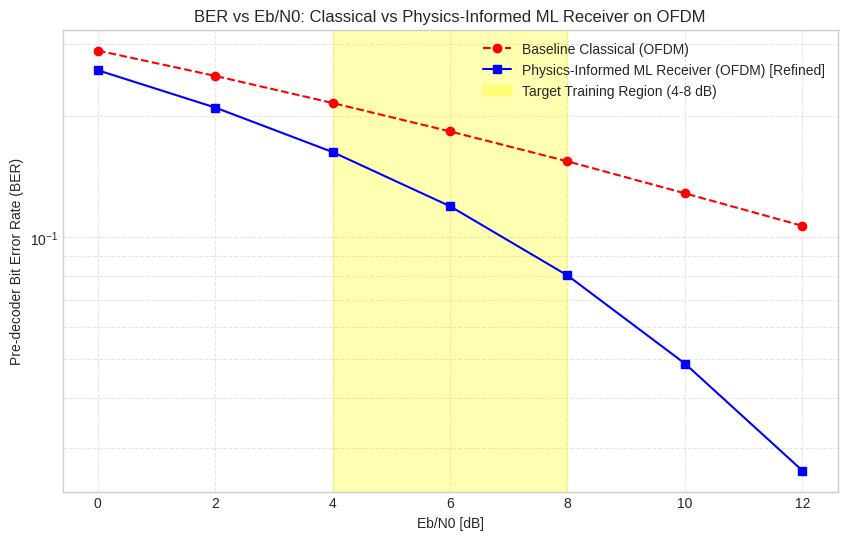

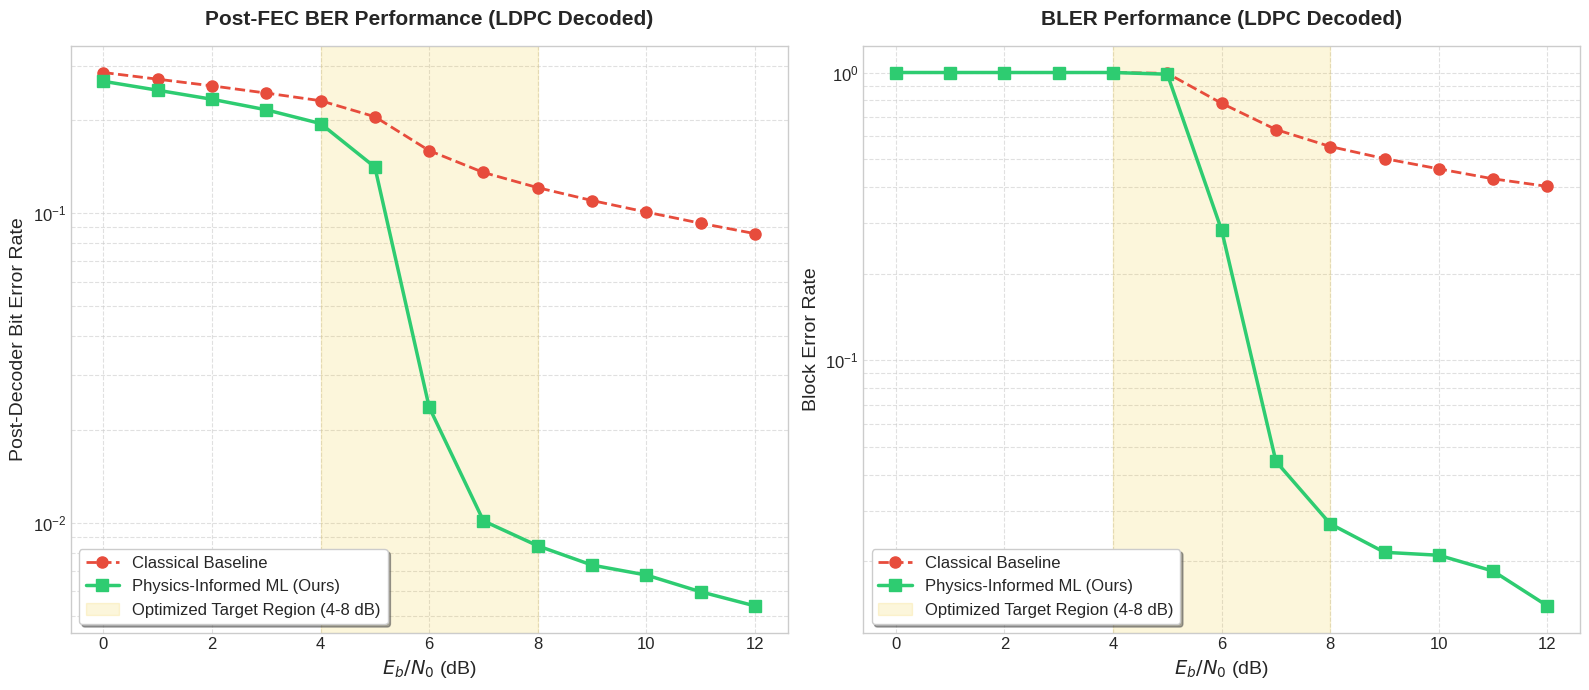

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

# ---- PLOT 1: PRE-FEC BER ----
plt.figure(figsize=(10, 6))
plt.semilogy(ebn0_range, ber_base_ofdm, 'r--o', label='Baseline Classical (OFDM)')
plt.semilogy(ebn0_range, ber_ml_ofdm, 'b-s', label='Physics-Informed ML Receiver (OFDM) [Refined]')
plt.axvspan(4, 8, color='yellow', alpha=0.3, label='Target Training Region (4-8 dB)')
plt.title("BER vs Eb/N0: Classical vs Physics-Informed ML Receiver on OFDM")
plt.xlabel("Eb/N0 [dB]")
plt.ylabel("Pre-decoder Bit Error Rate (BER)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

# ---- PLOT 2 & 3: POST-FEC BER & BLER ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

len_plot = min(len(ebn0_range_post), len(base_post_ber), len(ml_post_ber))
plot_x = list(ebn0_range_post)[:len_plot]

ax1.semilogy(plot_x, base_post_ber[:len_plot], color='#e74c3c', marker='o', linestyle='--',
             linewidth=2, markersize=8, label='Classical Baseline')
ax1.semilogy(plot_x, ml_post_ber[:len_plot], color='#2ecc71', marker='s', linestyle='-',
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax1.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax1.set_title("Post-FEC BER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax1.set_ylabel("Post-Decoder Bit Error Rate", fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.grid(True, which="both", ls="--", alpha=0.6)
ax1.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

ax2.semilogy(plot_x, base_bler[:len_plot], color='#e74c3c', marker='o', linestyle='--',
             linewidth=2, markersize=8, label='Classical Baseline')
ax2.semilogy(plot_x, ml_bler[:len_plot], color='#2ecc71', marker='s', linestyle='-',
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax2.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax2.set_title("BLER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax2.set_ylabel("Block Error Rate", fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.grid(True, which="both", ls="--", alpha=0.6)
ax2.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

### 6.4. Robustness Test: no curriculum learning (no teacher forcing)


GENERALIZATION TEST: FRESH 16-QAM DATA (NEW RANDOM SEEDS)
Eb/N0= 0.0 dB | BASE BER=3.631e-01 | ML (Fresh Data) BER=3.361e-01
Eb/N0= 2.0 dB | BASE BER=3.420e-01 | ML (Fresh Data) BER=3.136e-01
Eb/N0= 4.0 dB | BASE BER=3.180e-01 | ML (Fresh Data) BER=2.915e-01
Eb/N0= 6.0 dB | BASE BER=2.678e-01 | ML (Fresh Data) BER=2.385e-01
Eb/N0= 8.0 dB | BASE BER=2.283e-01 | ML (Fresh Data) BER=2.094e-01
Eb/N0=10.0 dB | BASE BER=1.940e-01 | ML (Fresh Data) BER=1.972e-01
Eb/N0=12.0 dB | BASE BER=1.633e-01 | ML (Fresh Data) BER=1.918e-01


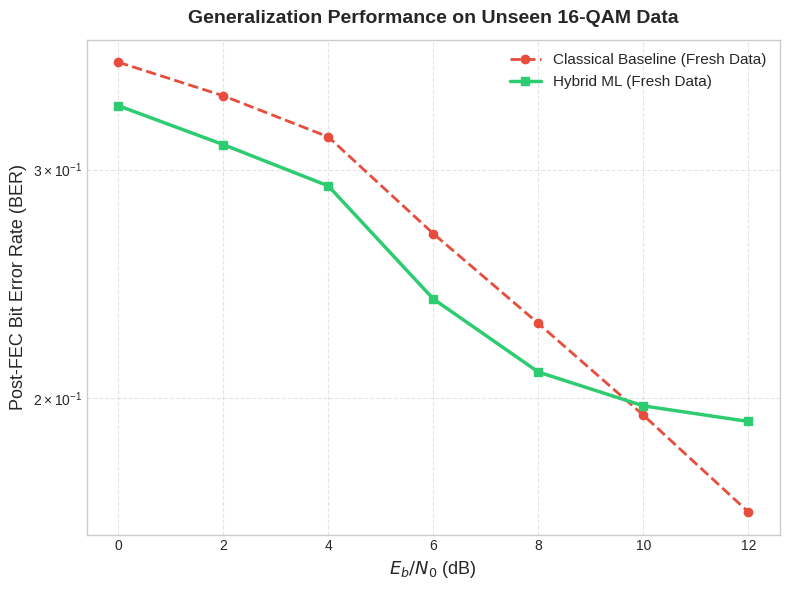

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import tensorflow as tf

print("\n" + "="*80)
print("GENERALIZATION TEST: FRESH 16-QAM DATA (NEW RANDOM SEEDS)")
print("="*80)

# 1. Define the Stress Test Configuration
cfg_fresh = SimConfig(**{
    **cfg_ofdm.__dict__,
    "num_examples": 5000,
    "seed": 999,          # Fresh user data bits

    # --- OUT OF DISTRIBUTION IMPAIRMENTS ---
    # The network was trained on [-2e-4, +2e-4].
    # Let's hit it with 3x the Doppler shift / Frequency Offset.
    "cfo_norm_min": -6e-4,
    "cfo_norm_max": +6e-4,
})

ebn0_range_eval = range(0, 13, 2)
fresh_base_ber, fresh_ml_ber = [], []
eval_batch_size = 500 # Prevents GPU OOM on 5000 examples

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_eval:
        cfg_eval = SimConfig(**{**cfg_fresh.__dict__, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # 2. Generate the fresh, unseen data
        full_tf = simulate_full_frames_tf(cfg_eval)
        ds_eval = generate_dataset_offline(cfg_eval)

        # 3. Classical Baseline Evaluation
        rx_base = classical_receiver(cfg_eval, full_tf)
        fresh_base_ber.append(rx_base["metrics"]["ber_post_info"])

        # 4. ML Model Evaluation (Batched)
        x_rx_t_full = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t_full = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        llr_ml_list = []

        # Process in chunks to keep memory safe
        for b in range(0, 5000, eval_batch_size):
            x_rx_batch = x_rx_t_full[b : b + eval_batch_size]
            x_pilot_batch = x_pilot_t_full[b : b + eval_batch_size]

            # Forward pass (mix_ratio=1.0 uses pure model estimation)
            bit_logits, _, _, _ = model_ofdm(x_rx_batch, x_pilot_batch, mix_ratio=1.0)
            llr_ml_batch = bit_logits.permute(0, 2, 1).reshape(bit_logits.size(0), -1).cpu().numpy()
            llr_ml_list.append(llr_ml_batch)

        llr_ml_np = np.concatenate(llr_ml_list, axis=0)

        # LLR Calibration
        snr_lin = 10 ** (ebno / 10.0)
        scale = snr_lin / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)
        llr_tf = tf.convert_to_tensor(llr_ml_np * scale, dtype=tf.float32)
        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        # LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        ml_ber_v = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        fresh_ml_ber.append(ml_ber_v)

        print(f"Eb/N0={ebno:4.1f} dB | BASE BER={fresh_base_ber[-1]:.3e} | ML (Fresh Data) BER={ml_ber_v:.3e}")

# --- Plotting the Generalization Curve ---
plt.figure(figsize=(8, 6))
plt.semilogy(ebn0_range_eval, fresh_base_ber, color='#e74c3c', marker='o', linestyle='--', linewidth=2, label='Classical Baseline (Fresh Data)')
plt.semilogy(ebn0_range_eval, fresh_ml_ber, color='#2ecc71', marker='s', linestyle='-', linewidth=2.5, label='Hybrid ML (Fresh Data)')
plt.title("Generalization Performance on Unseen 16-QAM Data", fontsize=14, fontweight='bold', pad=12)
plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=13)
plt.ylabel("Post-FEC Bit Error Rate (BER)", fontsize=13)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 7.1. Model training and validation: static auxiliary loss (no loss fading)

In [ ]:
train_loader, val_loader = get_pytorch_ofdm_loaders(cfg_ofdm, batch_size=128)

L_time = cfg_ofdm.ofdm_num_data_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)
P_time = cfg_ofdm.ofdm_num_pilot_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)

EPOCHS = 40

# ABLATION 2: STATIC AUXILIARY LOSS (NO LOSS FADING)
print("\n" + "="*80)
print("ABLATION 2: STATIC AUXILIARY LOSS (aux_w = 0.5 constant)")
print("="*80)

model_ofdm = HybridNeuralReceiverOFDM(
    seq_len=L_time, n_pilots=P_time,
    ofdm_fft_size=cfg_ofdm.ofdm_fft_size, ofdm_cp_len=cfg_ofdm.ofdm_cp_len
).to(DEVICE)

optimizer = torch.optim.AdamW(model_ofdm.parameters(), lr=2e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion_bce = nn.BCEWithLogitsLoss()
criterion_mse = nn.MSELoss()

for epoch in range(EPOCHS):
    model_ofdm.train()
    metrics = {'loss':0, 'phi':0, 'cfo':0, 'ber':0}

    mix = min(1.0, epoch / 10.0) # Keep teacher forcing

    # --- ABLATION CHANGE: Static Auxiliary Weight ---
    aux_w = 0.5

    for x, p, y_p, y_c, target_bits, target_iq in train_loader:
        x, p, y_p, y_c = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
        target_bits, target_iq = target_bits.to(DEVICE), target_iq.to(DEVICE)
        smooth_target_bits = target_bits * 0.98 + 0.01

        optimizer.zero_grad()
        bit_logits, est_phi, est_cfo, est_iq = model_ofdm(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=mix)

        loss_bits = criterion_bce(bit_logits, smooth_target_bits)
        loss_phi = criterion_mse(est_phi, y_p)
        loss_cfo = criterion_mse(est_cfo * 1000.0, y_c * 1000.0)
        loss_iq = criterion_mse(est_iq, target_iq)
        loss = loss_bits + aux_w * (0.5 * loss_phi + 0.5 * loss_cfo + 1.0 * loss_iq)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ofdm.parameters(), max_norm=1.0)
        optimizer.step()

        metrics['loss'] += loss.item()
        metrics['phi'] += torch.abs(est_phi - y_p).mean().item()
        with torch.no_grad():
            pred_bits = (bit_logits > 0).float()
            metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    scheduler.step()
    n_train = len(train_loader)
    model_ofdm.eval()
    val_metrics = {'loss':0, 'ber':0}
    with torch.no_grad():
        for x, p, y_p, y_c, target_bits, target_iq in val_loader:
            x, p, y_p, y_c = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
            target_bits, target_iq = target_bits.to(DEVICE), target_iq.to(DEVICE)
            bit_logits, est_phi, est_cfo, est_iq = model_ofdm(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=1.0)

            loss_bits = criterion_bce(bit_logits, target_bits)
            loss_phi = criterion_mse(est_phi, y_p)
            loss_cfo = criterion_mse(est_cfo * 1000.0, y_c * 1000.0)
            loss_iq = criterion_mse(est_iq, target_iq)
            loss = loss_bits + aux_w * (0.5 * loss_phi + 0.5 * loss_cfo + 1.0 * loss_iq)

            val_metrics['loss'] += loss.item()
            pred_bits = (bit_logits > 0).float()
            val_metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    n_val = len(val_loader)
    print(f"Ep {epoch+1:02d}/{EPOCHS} | Aux_W: {aux_w:.2f} | "
          f"Train Loss: {metrics['loss']/n_train:.4f} (BER: {metrics['ber']/n_train*100:.2f}%) | "
          f"Val Loss: {val_metrics['loss']/n_val:.4f} (BER: {val_metrics['ber']/n_val*100:.2f}%)")

Generating Specialized OFDM Dataset (80% in 4-8 dB range, 20% generalized)...

ABLATION 2: STATIC AUXILIARY LOSS (aux_w = 0.5 constant)
Ep 01/40 | Aux_W: 0.50 | Train Loss: 0.7588 (BER: 25.34%) | Val Loss: 0.8606 (BER: 24.76%)
Ep 02/40 | Aux_W: 0.50 | Train Loss: 0.4216 (BER: 12.31%) | Val Loss: 0.7123 (BER: 19.75%)
Ep 03/40 | Aux_W: 0.50 | Train Loss: 0.3959 (BER: 12.42%) | Val Loss: 0.6650 (BER: 18.62%)
Ep 04/40 | Aux_W: 0.50 | Train Loss: 0.4033 (BER: 12.69%) | Val Loss: 0.6606 (BER: 18.66%)
Ep 05/40 | Aux_W: 0.50 | Train Loss: 0.3919 (BER: 12.86%) | Val Loss: 0.6393 (BER: 17.34%)
Ep 06/40 | Aux_W: 0.50 | Train Loss: 0.3913 (BER: 13.29%) | Val Loss: 0.6722 (BER: 18.75%)
Ep 07/40 | Aux_W: 0.50 | Train Loss: 0.3891 (BER: 13.24%) | Val Loss: 0.6057 (BER: 15.63%)
Ep 08/40 | Aux_W: 0.50 | Train Loss: 0.3939 (BER: 13.55%) | Val Loss: 0.6011 (BER: 15.03%)
Ep 09/40 | Aux_W: 0.50 | Train Loss: 0.4035 (BER: 13.95%) | Val Loss: 0.6174 (BER: 15.94%)
Ep 10/40 | Aux_W: 0.50 | Train Loss: 0.4073 (

### 7.2. Model evaluation and prints: static auxiliary loss (no loss fading)

In [ ]:
import os
os.system('pip install thop -q')
try:
    from thop import profile
    has_thop = True
except ImportError:
    has_thop = False

# --- Highlight Complexity & Efficiency upfront ---
total_params = sum(p.numel() for p in model_ofdm.parameters())
trainable_params = sum(p.numel() for p in model_ofdm.parameters() if p.requires_grad)

print("\n" + "="*105)
print("MODEL COMPLEXITY & EFFICIENCY REPORT")
print("="*105)

print(f"[1] MODEL COMPLEXITY")
print(f" - Total Parameters:     {total_params:,}")
print(f" - Trainable Parameters: {trainable_params:,}")
print(f" - Model Size (Disk):    {total_params * 4 / (1024**2):.2f} MB")

if has_thop:
    try:
        dummy_x = torch.randn(1, 2, L_time).to(DEVICE)
        dummy_p = torch.randn(1, 2, P_time).to(DEVICE)
        dummy_phi = torch.randn(1).to(DEVICE)
        dummy_cfo = torch.randn(1).to(DEVICE)

        macs, params = profile(model_ofdm, inputs=(dummy_x, dummy_p, dummy_phi, dummy_cfo, 1.0), verbose=False)
        print(f" - MACs (Multiplies-Acc):{macs / 1e6:.2f} M")
        print(f" - FLOPs (Approx):       {macs * 2 / 1e6:.2f} MFLOPs")
    except Exception as e:
        print(" - FLOPs: Profiling error.")
else:
    print(" - FLOPs: Install 'thop' (pip install thop) for MACs calculation.")
print("-" * 105)

ebn0_range = range(0, 13, 2)
ber_base_ofdm, ber_ml_ofdm = [], []

print("\n--- Evaluating Baseline vs Physics-Informed ML Model (OFDM) ---")
model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        ber_base_ofdm.append(rx_base["metrics"]["ber_pre_coded"])

        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        target_bits_t = torch.tensor(ds_eval["coded_bits"]).reshape(-1, cfg_ofdm.seq_length, 4).permute(0, 2, 1).float().to(DEVICE)

        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)
        pred_bits = (bit_logits > 0).float()
        ml_ber = (pred_bits != target_bits_t).float().mean().item()
        ber_ml_ofdm.append(ml_ber)

        print(f"Eb/N0 = {ebno:02d} dB | Classical Baseline BER: {ber_base_ofdm[-1]:.4f} | ML BER: {ml_ber:.4f}")

# --- POST-FEC EVALUATION ---
ebn0_range_post = range(0, 13, 1)

base_post_ber, ml_post_ber = [], []
base_bler, ml_bler = [], []

print("\n" + "="*80)
print("POST-FEC BER & BLER EVALUATION (CALIBRATED LLR INTEGRATION)")
print("="*80)

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_post:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # --- CLASSICAL BASELINE ---
        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        m_base = rx_base["metrics"]
        base_post_ber.append(m_base["ber_post_info"])
        base_bler.append(m_base["bler_post_info"])

        # --- ML MODEL ---
        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        # 1. Inference (Raw logits extraction)
        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)
        B = bit_logits.size(0)
        llr_ml_np = bit_logits.permute(0, 2, 1).reshape(B, -1).cpu().numpy()

        # Pre-FEC BER
        pred_bits = (bit_logits > 0).float()
        # ml_pre_ber.append((pred_bits != target_bits_t).float().mean().item())

        # 2. LLR CALIBRATION
        snr_linear = 10 ** (ebno / 10.0)
        confidence_scaler = snr_linear / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)

        llr_tf = tf.convert_to_tensor(llr_ml_np * confidence_scaler, dtype=tf.float32)
        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        # 3. LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        # 4. Metric Calculation
        ml_ber_post = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        ml_bler_val = float(tf.reduce_mean(tf.cast(tf.reduce_any(info_hat != info_tf, axis=1), tf.float32)).numpy())

        ml_post_ber.append(ml_ber_post)
        ml_bler.append(ml_bler_val)

        # RESTORED: Real-time Eb/N0 output prints
        print(f"Eb/N0={ebno:4.1f} dB | BASE postBER={m_base['ber_post_info']:.3e} BLER={m_base['bler_post_info']:.3e} | "
              f"ML postBER={ml_ber_post:.3e} BLER={ml_bler_val:.3e}")


print("\n" + "="*105)
print("FINAL PERFORMANCE REPORT")
print("="*105)

print(f"\n[2] DECODED IMPROVEMENT RANGE (ML vs CLASSICAL)")
print(f"{'Eb/N0 (dB)':<11} | {'Base PostBER':<13} | {'ML PostBER':<13} | {'BER Imp (%)':<12} | {'Base BLER':<13} | {'ML BLER':<13} | {'BLER Imp (%)':<12}")
print("-" * 105)

for i, ebno in enumerate(ebn0_range_post):
    b_ber, m_ber = base_post_ber[i], ml_post_ber[i]
    b_bler, m_bler = base_bler[i], ml_bler[i]

    imp_ber = ((b_ber - m_ber) / b_ber) * 100 if b_ber > 0 else 0.0
    imp_ber_str = f"+{imp_ber:.2f}%" if imp_ber > 0 else f"{imp_ber:.2f}%"

    imp_bler = ((b_bler - m_bler) / b_bler) * 100 if b_bler > 0 else 0.0
    imp_bler_str = f"+{imp_bler:.2f}%" if imp_bler > 0 else f"{imp_bler:.2f}%"

    print(f"{ebno:<11.1f} | {b_ber:<13.3e} | {m_ber:<13.3e} | {imp_ber_str:<12} | {b_bler:<13.3e} | {m_bler:<13.3e} | {imp_bler_str:<12}")


MODEL COMPLEXITY & EFFICIENCY REPORT
[1] MODEL COMPLEXITY
 - Total Parameters:     276,888
 - Trainable Parameters: 276,888
 - Model Size (Disk):    1.06 MB
 - MACs (Multiplies-Acc):36.29 M
 - FLOPs (Approx):       72.57 MFLOPs
---------------------------------------------------------------------------------------------------------

--- Evaluating Baseline vs Physics-Informed ML Model (OFDM) ---
Eb/N0 = 00 dB | Classical Baseline BER: 0.2897 | ML BER: 0.2608
Eb/N0 = 02 dB | Classical Baseline BER: 0.2507 | ML BER: 0.2110
Eb/N0 = 04 dB | Classical Baseline BER: 0.2148 | ML BER: 0.1640
Eb/N0 = 06 dB | Classical Baseline BER: 0.1827 | ML BER: 0.1210
Eb/N0 = 08 dB | Classical Baseline BER: 0.1540 | ML BER: 0.0827
Eb/N0 = 10 dB | Classical Baseline BER: 0.1283 | ML BER: 0.0513
Eb/N0 = 12 dB | Classical Baseline BER: 0.1066 | ML BER: 0.0294

POST-FEC BER & BLER EVALUATION (CALIBRATED LLR INTEGRATION)
Eb/N0= 0.0 dB | BASE postBER=2.851e-01 BLER=1.000e+00 | ML postBER=2.673e-01 BLER=1.000e+00

### 7.3. Plots: static auxiliary loss (no loss fading)

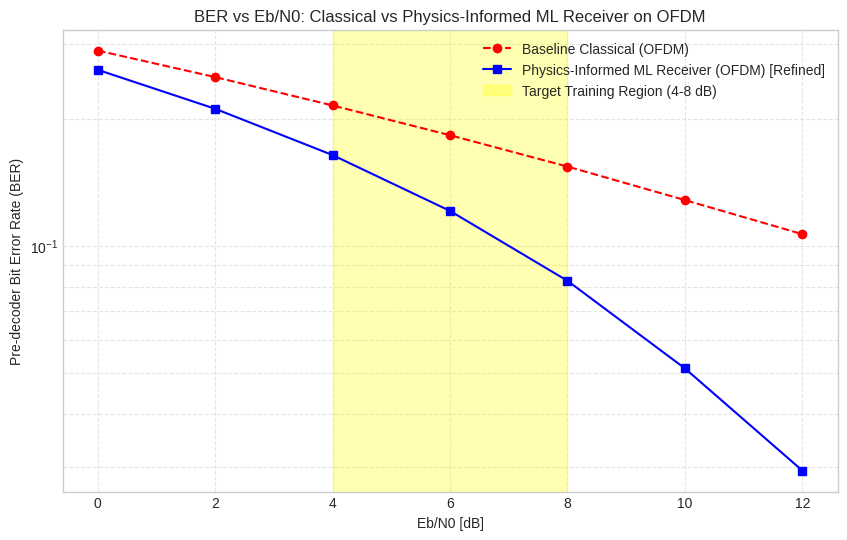

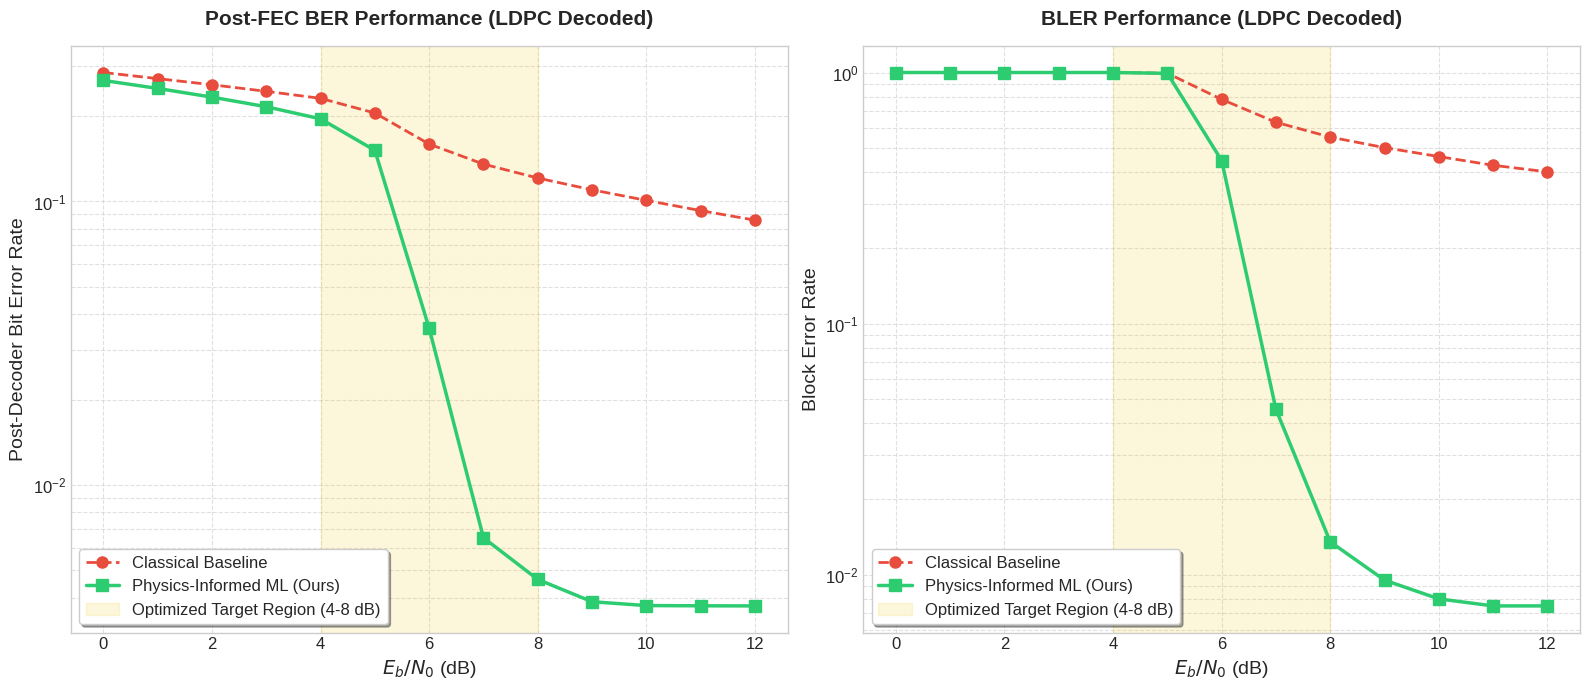

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

# ---- PLOT 1: PRE-FEC BER ----
plt.figure(figsize=(10, 6))
plt.semilogy(ebn0_range, ber_base_ofdm, 'r--o', label='Baseline Classical (OFDM)')
plt.semilogy(ebn0_range, ber_ml_ofdm, 'b-s', label='Physics-Informed ML Receiver (OFDM) [Refined]')
plt.axvspan(4, 8, color='yellow', alpha=0.3, label='Target Training Region (4-8 dB)')
plt.title("BER vs Eb/N0: Classical vs Physics-Informed ML Receiver on OFDM")
plt.xlabel("Eb/N0 [dB]")
plt.ylabel("Pre-decoder Bit Error Rate (BER)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

# ---- PLOT 2 & 3: POST-FEC BER & BLER ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

len_plot = min(len(ebn0_range_post), len(base_post_ber), len(ml_post_ber))
plot_x = list(ebn0_range_post)[:len_plot]

ax1.semilogy(plot_x, base_post_ber[:len_plot], color='#e74c3c', marker='o', linestyle='--',
             linewidth=2, markersize=8, label='Classical Baseline')
ax1.semilogy(plot_x, ml_post_ber[:len_plot], color='#2ecc71', marker='s', linestyle='-',
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax1.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax1.set_title("Post-FEC BER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax1.set_ylabel("Post-Decoder Bit Error Rate", fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.grid(True, which="both", ls="--", alpha=0.6)
ax1.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

ax2.semilogy(plot_x, base_bler[:len_plot], color='#e74c3c', marker='o', linestyle='--',
             linewidth=2, markersize=8, label='Classical Baseline')
ax2.semilogy(plot_x, ml_bler[:len_plot], color='#2ecc71', marker='s', linestyle='-',
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax2.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax2.set_title("BLER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax2.set_ylabel("Block Error Rate", fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.grid(True, which="both", ls="--", alpha=0.6)
ax2.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

### 7.4. Robustness Test: static auxiliary loss (no loss fading)


GENERALIZATION TEST: FRESH 16-QAM DATA (NEW RANDOM SEEDS)
Eb/N0= 0.0 dB | BASE BER=3.631e-01 | ML (Fresh Data) BER=3.353e-01
Eb/N0= 2.0 dB | BASE BER=3.420e-01 | ML (Fresh Data) BER=3.124e-01
Eb/N0= 4.0 dB | BASE BER=3.180e-01 | ML (Fresh Data) BER=2.896e-01
Eb/N0= 6.0 dB | BASE BER=2.678e-01 | ML (Fresh Data) BER=2.323e-01
Eb/N0= 8.0 dB | BASE BER=2.283e-01 | ML (Fresh Data) BER=2.024e-01
Eb/N0=10.0 dB | BASE BER=1.940e-01 | ML (Fresh Data) BER=1.910e-01
Eb/N0=12.0 dB | BASE BER=1.633e-01 | ML (Fresh Data) BER=1.851e-01


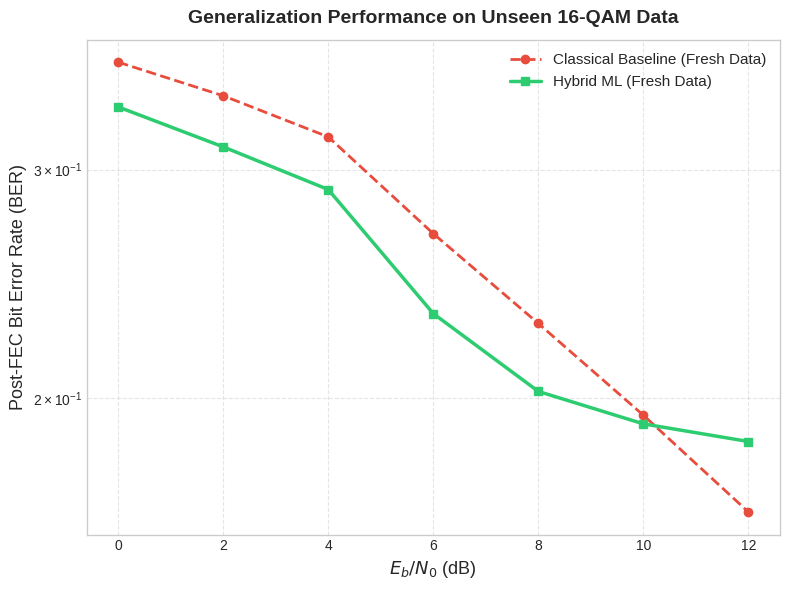

In [ ]:
print("\n" + "="*80)
print("GENERALIZATION TEST: FRESH 16-QAM DATA (NEW RANDOM SEEDS)")
print("="*80)

# 1. Define the Stress Test Configuration
# We unpack your original config, but overwrite specific keys for the OOD test.
cfg_fresh = SimConfig(**{
    **cfg_ofdm.__dict__,
    "num_examples": 5000,
    "seed": 999,          # Fresh user data bits

    # --- OUT OF DISTRIBUTION IMPAIRMENTS ---
    # The network was trained on [-2e-4, +2e-4].
    # Let's hit it with 3x the Doppler shift / Frequency Offset.
    "cfo_norm_min": -6e-4,
    "cfo_norm_max": +6e-4,

    # NOTE: If your SimConfig has a specific argument for phase noise jitter
    # (e.g., 'phase_noise_var' or 'pn_lin'), you should multiply it by 3x here too!
})

ebn0_range_eval = range(0, 13, 2)
fresh_base_ber, fresh_ml_ber = [], []
eval_batch_size = 500 # Prevents GPU OOM on 5000 examples

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_eval:
        cfg_eval = SimConfig(**{**cfg_fresh.__dict__, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # 2. Generate the fresh, unseen data
        full_tf = simulate_full_frames_tf(cfg_eval)
        ds_eval = generate_dataset_offline(cfg_eval)

        # 3. Classical Baseline Evaluation
        rx_base = classical_receiver(cfg_eval, full_tf)
        fresh_base_ber.append(rx_base["metrics"]["ber_post_info"])

        # 4. ML Model Evaluation (Batched)
        x_rx_t_full = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t_full = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        llr_ml_list = []

        # Process in chunks to keep memory safe
        for b in range(0, 5000, eval_batch_size):
            x_rx_batch = x_rx_t_full[b : b + eval_batch_size]
            x_pilot_batch = x_pilot_t_full[b : b + eval_batch_size]

            # Forward pass (mix_ratio=1.0 uses pure model estimation)
            bit_logits, _, _, _ = model_ofdm(x_rx_batch, x_pilot_batch, mix_ratio=1.0)
            llr_ml_batch = bit_logits.permute(0, 2, 1).reshape(bit_logits.size(0), -1).cpu().numpy()
            llr_ml_list.append(llr_ml_batch)

        llr_ml_np = np.concatenate(llr_ml_list, axis=0)

        # LLR Calibration
        snr_lin = 10 ** (ebno / 10.0)
        scale = snr_lin / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)
        llr_tf = tf.convert_to_tensor(llr_ml_np * scale, dtype=tf.float32)
        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        # LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        ml_ber_v = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        fresh_ml_ber.append(ml_ber_v)

        print(f"Eb/N0={ebno:4.1f} dB | BASE BER={fresh_base_ber[-1]:.3e} | ML (Fresh Data) BER={ml_ber_v:.3e}")

# --- Plotting the Generalization Curve ---
plt.figure(figsize=(8, 6))
plt.semilogy(ebn0_range_eval, fresh_base_ber, color='#e74c3c', marker='o', linestyle='--', linewidth=2, label='Classical Baseline (Fresh Data)')
plt.semilogy(ebn0_range_eval, fresh_ml_ber, color='#2ecc71', marker='s', linestyle='-', linewidth=2.5, label='Hybrid ML (Fresh Data)')
plt.title("Generalization Performance on Unseen 16-QAM Data", fontsize=14, fontweight='bold', pad=12)
plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=13)
plt.ylabel("Post-FEC Bit Error Rate (BER)", fontsize=13)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 8.1. Model training and validation: no label smoothing (hard targets only)

In [ ]:
train_loader, val_loader = get_pytorch_ofdm_loaders(cfg_ofdm, batch_size=128)

L_time = cfg_ofdm.ofdm_num_data_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)
P_time = cfg_ofdm.ofdm_num_pilot_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)

EPOCHS = 40

# ABLATION 3: NO LABEL SMOOTHING (HARD TARGETS ONLY)
print("\n" + "="*80)
print("ABLATION 3: NO LABEL SMOOTHING (Testing LDPC BLER robustness)")
print("="*80)

model_ofdm = HybridNeuralReceiverOFDM(
    seq_len=L_time, n_pilots=P_time,
    ofdm_fft_size=cfg_ofdm.ofdm_fft_size, ofdm_cp_len=cfg_ofdm.ofdm_cp_len
).to(DEVICE)

optimizer = torch.optim.AdamW(model_ofdm.parameters(), lr=2e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion_bce = nn.BCEWithLogitsLoss()
criterion_mse = nn.MSELoss()

for epoch in range(EPOCHS):
    model_ofdm.train()
    metrics = {'loss':0, 'phi':0, 'cfo':0, 'ber':0}

    mix = min(1.0, epoch / 10.0)
    aux_w = max(0.05, 1.0 - (epoch / (EPOCHS * 0.75)))

    for x, p, y_p, y_c, target_bits, target_iq in train_loader:
        x, p, y_p, y_c = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
        target_bits, target_iq = target_bits.to(DEVICE), target_iq.to(DEVICE)

        # --- ABLATION CHANGE: Removed Label Smoothing ---
        smooth_target_bits = target_bits

        optimizer.zero_grad()
        bit_logits, est_phi, est_cfo, est_iq = model_ofdm(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=mix)

        loss_bits = criterion_bce(bit_logits, smooth_target_bits)
        loss_phi = criterion_mse(est_phi, y_p)
        loss_cfo = criterion_mse(est_cfo * 1000.0, y_c * 1000.0)
        loss_iq = criterion_mse(est_iq, target_iq)
        loss = loss_bits + aux_w * (0.5 * loss_phi + 0.5 * loss_cfo + 1.0 * loss_iq)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ofdm.parameters(), max_norm=1.0)
        optimizer.step()

        metrics['loss'] += loss.item()
        metrics['phi'] += torch.abs(est_phi - y_p).mean().item()
        with torch.no_grad():
            pred_bits = (bit_logits > 0).float()
            metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    scheduler.step()
    n_train = len(train_loader)
    model_ofdm.eval()
    val_metrics = {'loss':0, 'ber':0}
    with torch.no_grad():
        for x, p, y_p, y_c, target_bits, target_iq in val_loader:
            x, p, y_p, y_c = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
            target_bits, target_iq = target_bits.to(DEVICE), target_iq.to(DEVICE)
            bit_logits, est_phi, est_cfo, est_iq = model_ofdm(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=1.0)

            loss_bits = criterion_bce(bit_logits, target_bits)
            loss_phi = criterion_mse(est_phi, y_p)
            loss_cfo = criterion_mse(est_cfo * 1000.0, y_c * 1000.0)
            loss_iq = criterion_mse(est_iq, target_iq)
            loss = loss_bits + aux_w * (0.5 * loss_phi + 0.5 * loss_cfo + 1.0 * loss_iq)

            val_metrics['loss'] += loss.item()
            pred_bits = (bit_logits > 0).float()
            val_metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    n_val = len(val_loader)
    print(f"Ep {epoch+1:02d}/{EPOCHS} | Mix: {mix:.2f} | "
          f"Train Loss: {metrics['loss']/n_train:.4f} (BER: {metrics['ber']/n_train*100:.2f}%) | "
          f"Val Loss: {val_metrics['loss']/n_val:.4f} (BER: {val_metrics['ber']/n_val*100:.2f}%)")

Generating Specialized OFDM Dataset (80% in 4-8 dB range, 20% generalized)...

ABLATION 3: NO LABEL SMOOTHING (Testing LDPC BLER robustness)
Ep 01/40 | Mix: 0.00 | Train Loss: 0.9893 (BER: 24.77%) | Val Loss: 1.0081 (BER: 23.06%)
Ep 02/40 | Mix: 0.10 | Train Loss: 0.5037 (BER: 12.39%) | Val Loss: 0.8442 (BER: 17.97%)
Ep 03/40 | Mix: 0.20 | Train Loss: 0.4412 (BER: 12.37%) | Val Loss: 0.8442 (BER: 18.24%)
Ep 04/40 | Mix: 0.30 | Train Loss: 0.4353 (BER: 12.65%) | Val Loss: 0.8524 (BER: 18.77%)
Ep 05/40 | Mix: 0.40 | Train Loss: 0.4296 (BER: 12.93%) | Val Loss: 0.7905 (BER: 17.39%)
Ep 06/40 | Mix: 0.50 | Train Loss: 0.4203 (BER: 13.20%) | Val Loss: 0.7917 (BER: 17.94%)
Ep 07/40 | Mix: 0.60 | Train Loss: 0.4133 (BER: 13.49%) | Val Loss: 0.7183 (BER: 16.11%)
Ep 08/40 | Mix: 0.70 | Train Loss: 0.4132 (BER: 13.67%) | Val Loss: 0.6734 (BER: 15.23%)
Ep 09/40 | Mix: 0.80 | Train Loss: 0.4044 (BER: 13.73%) | Val Loss: 0.6632 (BER: 15.62%)
Ep 10/40 | Mix: 0.90 | Train Loss: 0.4213 (BER: 14.39%) | 

### 8.2. Model evaluation and prints: no label smoothing (hard targets only)

In [ ]:
import os
os.system('pip install thop -q')
try:
    from thop import profile
    has_thop = True
except ImportError:
    has_thop = False

# --- Highlight Complexity & Efficiency upfront ---
total_params = sum(p.numel() for p in model_ofdm.parameters())
trainable_params = sum(p.numel() for p in model_ofdm.parameters() if p.requires_grad)

print("\n" + "="*105)
print("MODEL COMPLEXITY & EFFICIENCY REPORT")
print("="*105)

print(f"[1] MODEL COMPLEXITY")
print(f" - Total Parameters:     {total_params:,}")
print(f" - Trainable Parameters: {trainable_params:,}")
print(f" - Model Size (Disk):    {total_params * 4 / (1024**2):.2f} MB")

if has_thop:
    try:
        dummy_x = torch.randn(1, 2, L_time).to(DEVICE)
        dummy_p = torch.randn(1, 2, P_time).to(DEVICE)
        dummy_phi = torch.randn(1).to(DEVICE)
        dummy_cfo = torch.randn(1).to(DEVICE)

        macs, params = profile(model_ofdm, inputs=(dummy_x, dummy_p, dummy_phi, dummy_cfo, 1.0), verbose=False)
        print(f" - MACs (Multiplies-Acc):{macs / 1e6:.2f} M")
        print(f" - FLOPs (Approx):       {macs * 2 / 1e6:.2f} MFLOPs")
    except Exception as e:
        print(" - FLOPs: Profiling error.")
else:
    print(" - FLOPs: Install 'thop' (pip install thop) for MACs calculation.")
print("-" * 105)

ebn0_range = range(0, 13, 2)
ber_base_ofdm, ber_ml_ofdm = [], []

print("\n--- Evaluating Baseline vs Physics-Informed ML Model (OFDM) ---")
model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        ber_base_ofdm.append(rx_base["metrics"]["ber_pre_coded"])

        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        target_bits_t = torch.tensor(ds_eval["coded_bits"]).reshape(-1, cfg_ofdm.seq_length, 4).permute(0, 2, 1).float().to(DEVICE)

        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)
        pred_bits = (bit_logits > 0).float()
        ml_ber = (pred_bits != target_bits_t).float().mean().item()
        ber_ml_ofdm.append(ml_ber)

        print(f"Eb/N0 = {ebno:02d} dB | Classical Baseline BER: {ber_base_ofdm[-1]:.4f} | ML BER: {ml_ber:.4f}")

# --- POST-FEC EVALUATION ---
ebn0_range_post = range(0, 13, 1)

base_post_ber, ml_post_ber = [], []
base_bler, ml_bler = [], []

print("\n" + "="*80)
print("POST-FEC BER & BLER EVALUATION (CALIBRATED LLR INTEGRATION)")
print("="*80)

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_post:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # --- CLASSICAL BASELINE ---
        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        m_base = rx_base["metrics"]
        base_post_ber.append(m_base["ber_post_info"])
        base_bler.append(m_base["bler_post_info"])

        # --- ML MODEL ---
        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        # 1. Inference (Raw logits extraction)
        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)
        B = bit_logits.size(0)
        llr_ml_np = bit_logits.permute(0, 2, 1).reshape(B, -1).cpu().numpy()

        # Pre-FEC BER
        pred_bits = (bit_logits > 0).float()
        # ml_pre_ber.append((pred_bits != target_bits_t).float().mean().item())

        # 2. LLR CALIBRATION
        snr_linear = 10 ** (ebno / 10.0)
        confidence_scaler = snr_linear / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)

        llr_tf = tf.convert_to_tensor(llr_ml_np * confidence_scaler, dtype=tf.float32)
        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        # 3. LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        # 4. Metric Calculation
        ml_ber_post = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        ml_bler_val = float(tf.reduce_mean(tf.cast(tf.reduce_any(info_hat != info_tf, axis=1), tf.float32)).numpy())

        ml_post_ber.append(ml_ber_post)
        ml_bler.append(ml_bler_val)

        # RESTORED: Real-time Eb/N0 output prints
        print(f"Eb/N0={ebno:4.1f} dB | BASE postBER={m_base['ber_post_info']:.3e} BLER={m_base['bler_post_info']:.3e} | "
              f"ML postBER={ml_ber_post:.3e} BLER={ml_bler_val:.3e}")


print("\n" + "="*105)
print("FINAL PERFORMANCE REPORT")
print("="*105)

print(f"\n[2] DECODED IMPROVEMENT RANGE (ML vs CLASSICAL)")
print(f"{'Eb/N0 (dB)':<11} | {'Base PostBER':<13} | {'ML PostBER':<13} | {'BER Imp (%)':<12} | {'Base BLER':<13} | {'ML BLER':<13} | {'BLER Imp (%)':<12}")
print("-" * 105)

for i, ebno in enumerate(ebn0_range_post):
    b_ber, m_ber = base_post_ber[i], ml_post_ber[i]
    b_bler, m_bler = base_bler[i], ml_bler[i]

    imp_ber = ((b_ber - m_ber) / b_ber) * 100 if b_ber > 0 else 0.0
    imp_ber_str = f"+{imp_ber:.2f}%" if imp_ber > 0 else f"{imp_ber:.2f}%"

    imp_bler = ((b_bler - m_bler) / b_bler) * 100 if b_bler > 0 else 0.0
    imp_bler_str = f"+{imp_bler:.2f}%" if imp_bler > 0 else f"{imp_bler:.2f}%"

    print(f"{ebno:<11.1f} | {b_ber:<13.3e} | {m_ber:<13.3e} | {imp_ber_str:<12} | {b_bler:<13.3e} | {m_bler:<13.3e} | {imp_bler_str:<12}")


MODEL COMPLEXITY & EFFICIENCY REPORT
[1] MODEL COMPLEXITY
 - Total Parameters:     276,888
 - Trainable Parameters: 276,888
 - Model Size (Disk):    1.06 MB
 - MACs (Multiplies-Acc):36.29 M
 - FLOPs (Approx):       72.57 MFLOPs
---------------------------------------------------------------------------------------------------------

--- Evaluating Baseline vs Physics-Informed ML Model (OFDM) ---
Eb/N0 = 00 dB | Classical Baseline BER: 0.2897 | ML BER: 0.2606
Eb/N0 = 02 dB | Classical Baseline BER: 0.2507 | ML BER: 0.2099
Eb/N0 = 04 dB | Classical Baseline BER: 0.2148 | ML BER: 0.1629
Eb/N0 = 06 dB | Classical Baseline BER: 0.1827 | ML BER: 0.1199
Eb/N0 = 08 dB | Classical Baseline BER: 0.1540 | ML BER: 0.0813
Eb/N0 = 10 dB | Classical Baseline BER: 0.1283 | ML BER: 0.0500
Eb/N0 = 12 dB | Classical Baseline BER: 0.1066 | ML BER: 0.0283

POST-FEC BER & BLER EVALUATION (CALIBRATED LLR INTEGRATION)
Eb/N0= 0.0 dB | BASE postBER=2.851e-01 BLER=1.000e+00 | ML postBER=2.678e-01 BLER=1.000e+00

### 8.3. Plots: no label smoothing (hard targets only)

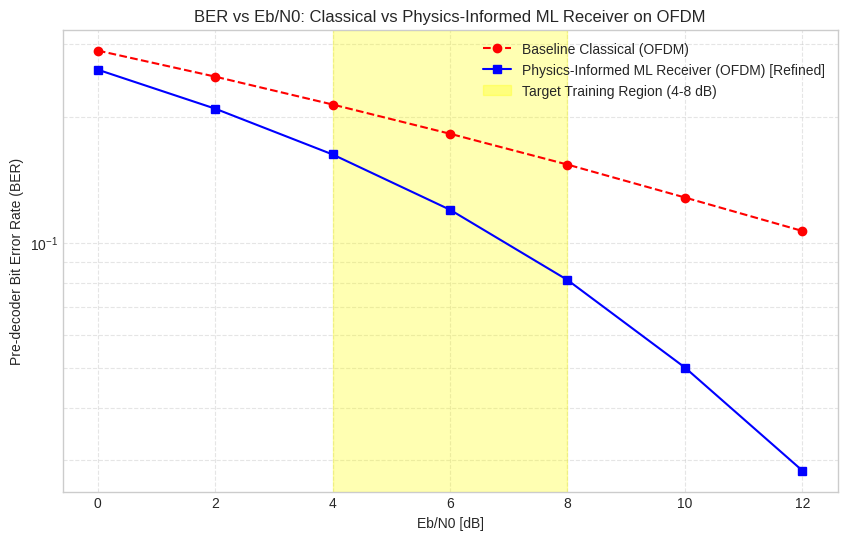

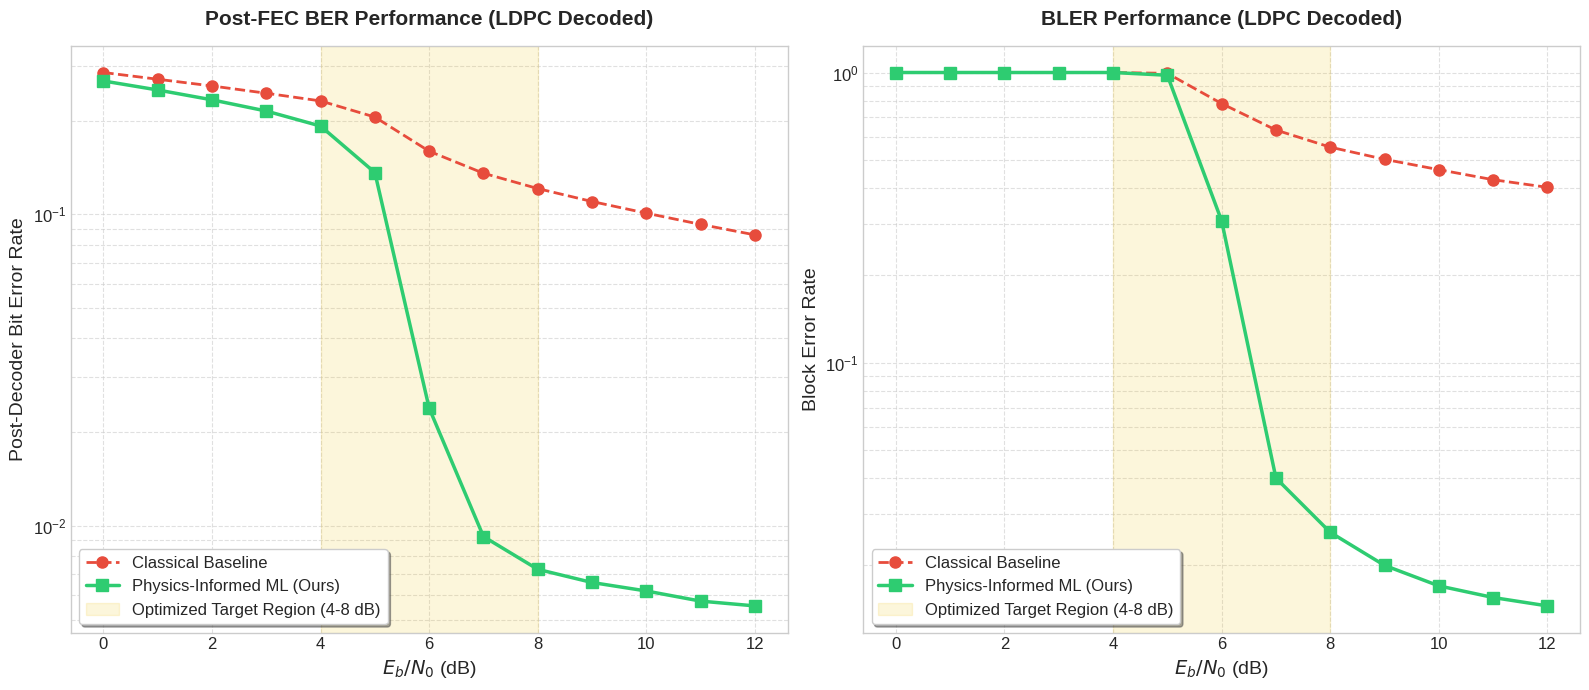

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

# ---- PLOT 1: PRE-FEC BER ----
plt.figure(figsize=(10, 6))
plt.semilogy(ebn0_range, ber_base_ofdm, 'r--o', label='Baseline Classical (OFDM)')
plt.semilogy(ebn0_range, ber_ml_ofdm, 'b-s', label='Physics-Informed ML Receiver (OFDM) [Refined]')
plt.axvspan(4, 8, color='yellow', alpha=0.3, label='Target Training Region (4-8 dB)')
plt.title("BER vs Eb/N0: Classical vs Physics-Informed ML Receiver on OFDM")
plt.xlabel("Eb/N0 [dB]")
plt.ylabel("Pre-decoder Bit Error Rate (BER)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

# ---- PLOT 2 & 3: POST-FEC BER & BLER ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

len_plot = min(len(ebn0_range_post), len(base_post_ber), len(ml_post_ber))
plot_x = list(ebn0_range_post)[:len_plot]

ax1.semilogy(plot_x, base_post_ber[:len_plot], color='#e74c3c', marker='o', linestyle='--',
             linewidth=2, markersize=8, label='Classical Baseline')
ax1.semilogy(plot_x, ml_post_ber[:len_plot], color='#2ecc71', marker='s', linestyle='-',
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax1.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax1.set_title("Post-FEC BER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax1.set_ylabel("Post-Decoder Bit Error Rate", fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.grid(True, which="both", ls="--", alpha=0.6)
ax1.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

ax2.semilogy(plot_x, base_bler[:len_plot], color='#e74c3c', marker='o', linestyle='--',
             linewidth=2, markersize=8, label='Classical Baseline')
ax2.semilogy(plot_x, ml_bler[:len_plot], color='#2ecc71', marker='s', linestyle='-',
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax2.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax2.set_title("BLER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax2.set_ylabel("Block Error Rate", fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.grid(True, which="both", ls="--", alpha=0.6)
ax2.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

### 8.4. Robustness Test: no label smoothing (hard targets only)


GENERALIZATION TEST: FRESH 16-QAM DATA (NEW RANDOM SEEDS)
Eb/N0= 0.0 dB | BASE BER=3.631e-01 | ML (Fresh Data) BER=3.358e-01
Eb/N0= 2.0 dB | BASE BER=3.420e-01 | ML (Fresh Data) BER=3.123e-01
Eb/N0= 4.0 dB | BASE BER=3.180e-01 | ML (Fresh Data) BER=2.895e-01
Eb/N0= 6.0 dB | BASE BER=2.678e-01 | ML (Fresh Data) BER=2.327e-01
Eb/N0= 8.0 dB | BASE BER=2.283e-01 | ML (Fresh Data) BER=2.051e-01
Eb/N0=10.0 dB | BASE BER=1.940e-01 | ML (Fresh Data) BER=1.946e-01
Eb/N0=12.0 dB | BASE BER=1.633e-01 | ML (Fresh Data) BER=1.906e-01


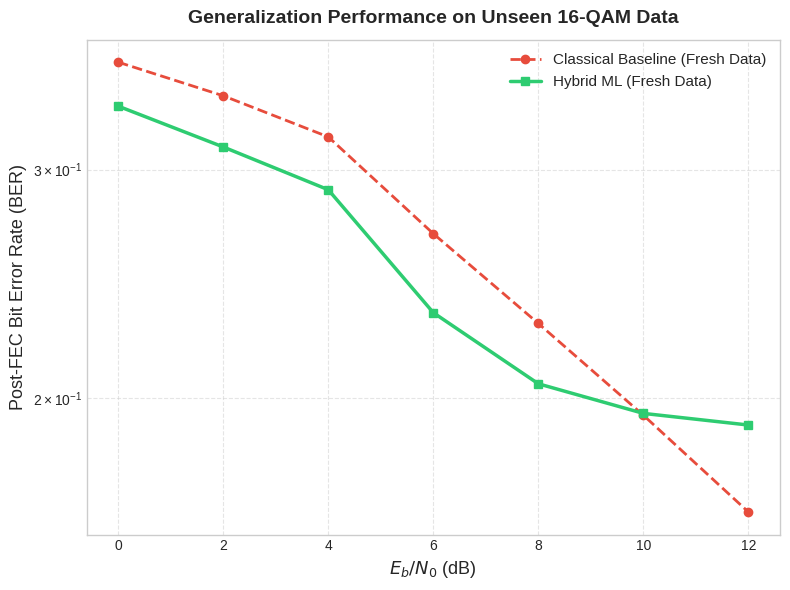

In [ ]:
print("\n" + "="*80)
print("GENERALIZATION TEST: FRESH 16-QAM DATA (NEW RANDOM SEEDS)")
print("="*80)

# 1. Define the Stress Test Configuration
cfg_fresh = SimConfig(**{
    **cfg_ofdm.__dict__,
    "num_examples": 5000,
    "seed": 999,          # Fresh user data bits

    # --- OUT OF DISTRIBUTION IMPAIRMENTS ---
    # The network was trained on [-2e-4, +2e-4].
    # Let's hit it with 3x the Doppler shift / Frequency Offset.
    "cfo_norm_min": -6e-4,
    "cfo_norm_max": +6e-4,

})

ebn0_range_eval = range(0, 13, 2)
fresh_base_ber, fresh_ml_ber = [], []
eval_batch_size = 500 # Prevents GPU OOM on 5000 examples

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_eval:
        cfg_eval = SimConfig(**{**cfg_fresh.__dict__, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # 2. Generate the fresh, unseen data
        full_tf = simulate_full_frames_tf(cfg_eval)
        ds_eval = generate_dataset_offline(cfg_eval)

        # 3. Classical Baseline Evaluation
        rx_base = classical_receiver(cfg_eval, full_tf)
        fresh_base_ber.append(rx_base["metrics"]["ber_post_info"])

        # 4. ML Model Evaluation (Batched)
        x_rx_t_full = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t_full = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        llr_ml_list = []

        # Process in chunks to keep memory safe
        for b in range(0, 5000, eval_batch_size):
            x_rx_batch = x_rx_t_full[b : b + eval_batch_size]
            x_pilot_batch = x_pilot_t_full[b : b + eval_batch_size]

            # Forward pass (mix_ratio=1.0 uses pure model estimation)
            bit_logits, _, _, _ = model_ofdm(x_rx_batch, x_pilot_batch, mix_ratio=1.0)
            llr_ml_batch = bit_logits.permute(0, 2, 1).reshape(bit_logits.size(0), -1).cpu().numpy()
            llr_ml_list.append(llr_ml_batch)

        llr_ml_np = np.concatenate(llr_ml_list, axis=0)

        # LLR Calibration
        snr_lin = 10 ** (ebno / 10.0)
        scale = snr_lin / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)
        llr_tf = tf.convert_to_tensor(llr_ml_np * scale, dtype=tf.float32)
        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        # LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        ml_ber_v = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        fresh_ml_ber.append(ml_ber_v)

        print(f"Eb/N0={ebno:4.1f} dB | BASE BER={fresh_base_ber[-1]:.3e} | ML (Fresh Data) BER={ml_ber_v:.3e}")

# --- Plotting the Generalization Curve ---
plt.figure(figsize=(8, 6))
plt.semilogy(ebn0_range_eval, fresh_base_ber, color='#e74c3c', marker='o', linestyle='--', linewidth=2, label='Classical Baseline (Fresh Data)')
plt.semilogy(ebn0_range_eval, fresh_ml_ber, color='#2ecc71', marker='s', linestyle='-', linewidth=2.5, label='Hybrid ML (Fresh Data)')
plt.title("Generalization Performance on Unseen 16-QAM Data", fontsize=14, fontweight='bold', pad=12)
plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=13)
plt.ylabel("Post-FEC Bit Error Rate (BER)", fontsize=13)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 9.1. Model training and validation: pure e2e black-box (no physics loss guidance)

In [ ]:
train_loader, val_loader = get_pytorch_ofdm_loaders(cfg_ofdm, batch_size=128)

L_time = cfg_ofdm.ofdm_num_data_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)
P_time = cfg_ofdm.ofdm_num_pilot_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)

EPOCHS = 40

# ABLATION 4: PURE E2E BLACK-BOX (NO PHYSICS LOSS GUIDANCE)
print("\n" + "="*80)
print("ABLATION 4: PURE BLACK-BOX (aux_w = 0.0, No physics loss)")
print("="*80)

model_ofdm = HybridNeuralReceiverOFDM(
    seq_len=L_time, n_pilots=P_time,
    ofdm_fft_size=cfg_ofdm.ofdm_fft_size, ofdm_cp_len=cfg_ofdm.ofdm_cp_len
).to(DEVICE)

optimizer = torch.optim.AdamW(model_ofdm.parameters(), lr=2e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion_bce = nn.BCEWithLogitsLoss()

for epoch in range(EPOCHS):
    model_ofdm.train()
    metrics = {'loss':0, 'phi':0, 'cfo':0, 'ber':0}

    # --- ABLATION CHANGE: No Teacher Forcing, No Aux Loss ---
    mix = 1.0
    aux_w = 0.0

    for x, p, y_p, y_c, target_bits, target_iq in train_loader:
        x, p, y_p, y_c = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
        target_bits, target_iq = target_bits.to(DEVICE), target_iq.to(DEVICE)
        smooth_target_bits = target_bits * 0.98 + 0.01

        optimizer.zero_grad()
        bit_logits, est_phi, est_cfo, est_iq = model_ofdm(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=mix)

        # Loss is ONLY the Bit Cross-Entropy
        loss = criterion_bce(bit_logits, smooth_target_bits)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ofdm.parameters(), max_norm=1.0)
        optimizer.step()

        metrics['loss'] += loss.item()
        metrics['phi'] += torch.abs(est_phi - y_p).mean().item() # Still track for logs, but not loss
        with torch.no_grad():
            pred_bits = (bit_logits > 0).float()
            metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    scheduler.step()
    n_train = len(train_loader)
    model_ofdm.eval()
    val_metrics = {'loss':0, 'ber':0}
    with torch.no_grad():
        for x, p, y_p, y_c, target_bits, target_iq in val_loader:
            x, p, y_p, y_c = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
            target_bits, target_iq = target_bits.to(DEVICE), target_iq.to(DEVICE)
            bit_logits, est_phi, est_cfo, est_iq = model_ofdm(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=1.0)

            loss = criterion_bce(bit_logits, target_bits)

            val_metrics['loss'] += loss.item()
            pred_bits = (bit_logits > 0).float()
            val_metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    n_val = len(val_loader)
    print(f"Ep {epoch+1:02d}/{EPOCHS} | E2E Black-Box | "
          f"Train Loss: {metrics['loss']/n_train:.4f} (BER: {metrics['ber']/n_train*100:.2f}%) | "
          f"Val Loss: {val_metrics['loss']/n_val:.4f} (BER: {val_metrics['ber']/n_val*100:.2f}%)")

Generating Specialized OFDM Dataset (80% in 4-8 dB range, 20% generalized)...

ABLATION 4: PURE BLACK-BOX (aux_w = 0.0, No physics loss)
Ep 01/40 | E2E Black-Box | Train Loss: 0.5189 (BER: 26.30%) | Val Loss: 0.4447 (BER: 20.40%)
Ep 02/40 | E2E Black-Box | Train Loss: 0.3988 (BER: 18.03%) | Val Loss: 0.3770 (BER: 17.51%)
Ep 03/40 | E2E Black-Box | Train Loss: 0.3642 (BER: 15.84%) | Val Loss: 0.3590 (BER: 16.29%)
Ep 04/40 | E2E Black-Box | Train Loss: 0.3431 (BER: 14.39%) | Val Loss: 0.3621 (BER: 16.35%)
Ep 05/40 | E2E Black-Box | Train Loss: 0.3320 (BER: 13.76%) | Val Loss: 0.3300 (BER: 14.81%)
Ep 06/40 | E2E Black-Box | Train Loss: 0.3231 (BER: 13.29%) | Val Loss: 0.3274 (BER: 14.81%)
Ep 07/40 | E2E Black-Box | Train Loss: 0.3247 (BER: 13.35%) | Val Loss: 0.3437 (BER: 15.52%)
Ep 08/40 | E2E Black-Box | Train Loss: 0.3253 (BER: 13.38%) | Val Loss: 0.3276 (BER: 14.88%)
Ep 09/40 | E2E Black-Box | Train Loss: 0.3167 (BER: 12.92%) | Val Loss: 0.3271 (BER: 14.66%)
Ep 10/40 | E2E Black-Box |

### 9.2. Model evaluation and prints: pure e2e black-box (no physics loss guidance)

In [ ]:
import os
os.system('pip install thop -q')
try:
    from thop import profile
    has_thop = True
except ImportError:
    has_thop = False

# --- Highlight Complexity & Efficiency upfront ---
total_params = sum(p.numel() for p in model_ofdm.parameters())
trainable_params = sum(p.numel() for p in model_ofdm.parameters() if p.requires_grad)

print("\n" + "="*105)
print("MODEL COMPLEXITY & EFFICIENCY REPORT")
print("="*105)

print(f"[1] MODEL COMPLEXITY")
print(f" - Total Parameters:     {total_params:,}")
print(f" - Trainable Parameters: {trainable_params:,}")
print(f" - Model Size (Disk):    {total_params * 4 / (1024**2):.2f} MB")

if has_thop:
    try:
        dummy_x = torch.randn(1, 2, L_time).to(DEVICE)
        dummy_p = torch.randn(1, 2, P_time).to(DEVICE)
        dummy_phi = torch.randn(1).to(DEVICE)
        dummy_cfo = torch.randn(1).to(DEVICE)

        macs, params = profile(model_ofdm, inputs=(dummy_x, dummy_p, dummy_phi, dummy_cfo, 1.0), verbose=False)
        print(f" - MACs (Multiplies-Acc):{macs / 1e6:.2f} M")
        print(f" - FLOPs (Approx):       {macs * 2 / 1e6:.2f} MFLOPs")
    except Exception as e:
        print(" - FLOPs: Profiling error.")
else:
    print(" - FLOPs: Install 'thop' (pip install thop) for MACs calculation.")
print("-" * 105)

ebn0_range = range(0, 13, 2)
ber_base_ofdm, ber_ml_ofdm = [], []

print("\n--- Evaluating Baseline vs Physics-Informed ML Model (OFDM) ---")
model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        ber_base_ofdm.append(rx_base["metrics"]["ber_pre_coded"])

        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        target_bits_t = torch.tensor(ds_eval["coded_bits"]).reshape(-1, cfg_ofdm.seq_length, 4).permute(0, 2, 1).float().to(DEVICE)

        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)
        pred_bits = (bit_logits > 0).float()
        ml_ber = (pred_bits != target_bits_t).float().mean().item()
        ber_ml_ofdm.append(ml_ber)

        print(f"Eb/N0 = {ebno:02d} dB | Classical Baseline BER: {ber_base_ofdm[-1]:.4f} | ML BER: {ml_ber:.4f}")

# --- POST-FEC EVALUATION ---
ebn0_range_post = range(0, 13, 1)

base_post_ber, ml_post_ber = [], []
base_bler, ml_bler = [], []

print("\n" + "="*80)
print("POST-FEC BER & BLER EVALUATION (CALIBRATED LLR INTEGRATION)")
print("="*80)

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_post:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # --- CLASSICAL BASELINE ---
        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        m_base = rx_base["metrics"]
        base_post_ber.append(m_base["ber_post_info"])
        base_bler.append(m_base["bler_post_info"])

        # --- ML MODEL ---
        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        # 1. Inference (Raw logits extraction)
        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)
        B = bit_logits.size(0)
        llr_ml_np = bit_logits.permute(0, 2, 1).reshape(B, -1).cpu().numpy()

        # Pre-FEC BER
        pred_bits = (bit_logits > 0).float()
        # ml_pre_ber.append((pred_bits != target_bits_t).float().mean().item())

        # 2. LLR CALIBRATION
        snr_linear = 10 ** (ebno / 10.0)
        confidence_scaler = snr_linear / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)

        llr_tf = tf.convert_to_tensor(llr_ml_np * confidence_scaler, dtype=tf.float32)
        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        # 3. LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        # 4. Metric Calculation
        ml_ber_post = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        ml_bler_val = float(tf.reduce_mean(tf.cast(tf.reduce_any(info_hat != info_tf, axis=1), tf.float32)).numpy())

        ml_post_ber.append(ml_ber_post)
        ml_bler.append(ml_bler_val)

        # RESTORED: Real-time Eb/N0 output prints
        print(f"Eb/N0={ebno:4.1f} dB | BASE postBER={m_base['ber_post_info']:.3e} BLER={m_base['bler_post_info']:.3e} | "
              f"ML postBER={ml_ber_post:.3e} BLER={ml_bler_val:.3e}")


print("\n" + "="*105)
print("FINAL PERFORMANCE REPORT")
print("="*105)

print(f"\n[2] DECODED IMPROVEMENT RANGE (ML vs CLASSICAL)")
print(f"{'Eb/N0 (dB)':<11} | {'Base PostBER':<13} | {'ML PostBER':<13} | {'BER Imp (%)':<12} | {'Base BLER':<13} | {'ML BLER':<13} | {'BLER Imp (%)':<12}")
print("-" * 105)

for i, ebno in enumerate(ebn0_range_post):
    b_ber, m_ber = base_post_ber[i], ml_post_ber[i]
    b_bler, m_bler = base_bler[i], ml_bler[i]

    imp_ber = ((b_ber - m_ber) / b_ber) * 100 if b_ber > 0 else 0.0
    imp_ber_str = f"+{imp_ber:.2f}%" if imp_ber > 0 else f"{imp_ber:.2f}%"

    imp_bler = ((b_bler - m_bler) / b_bler) * 100 if b_bler > 0 else 0.0
    imp_bler_str = f"+{imp_bler:.2f}%" if imp_bler > 0 else f"{imp_bler:.2f}%"

    print(f"{ebno:<11.1f} | {b_ber:<13.3e} | {m_ber:<13.3e} | {imp_ber_str:<12} | {b_bler:<13.3e} | {m_bler:<13.3e} | {imp_bler_str:<12}")


MODEL COMPLEXITY & EFFICIENCY REPORT
[1] MODEL COMPLEXITY
 - Total Parameters:     276,888
 - Trainable Parameters: 276,888
 - Model Size (Disk):    1.06 MB
 - MACs (Multiplies-Acc):36.29 M
 - FLOPs (Approx):       72.57 MFLOPs
---------------------------------------------------------------------------------------------------------

--- Evaluating Baseline vs Physics-Informed ML Model (OFDM) ---
Eb/N0 = 00 dB | Classical Baseline BER: 0.2897 | ML BER: 0.2581
Eb/N0 = 02 dB | Classical Baseline BER: 0.2507 | ML BER: 0.2071
Eb/N0 = 04 dB | Classical Baseline BER: 0.2148 | ML BER: 0.1596
Eb/N0 = 06 dB | Classical Baseline BER: 0.1827 | ML BER: 0.1158
Eb/N0 = 08 dB | Classical Baseline BER: 0.1540 | ML BER: 0.0768
Eb/N0 = 10 dB | Classical Baseline BER: 0.1283 | ML BER: 0.0450
Eb/N0 = 12 dB | Classical Baseline BER: 0.1066 | ML BER: 0.0237

POST-FEC BER & BLER EVALUATION (CALIBRATED LLR INTEGRATION)
Eb/N0= 0.0 dB | BASE postBER=2.851e-01 BLER=1.000e+00 | ML postBER=2.656e-01 BLER=1.000e+00

### 9.3. Plots: pure e2e black-box (no physics loss guidance)

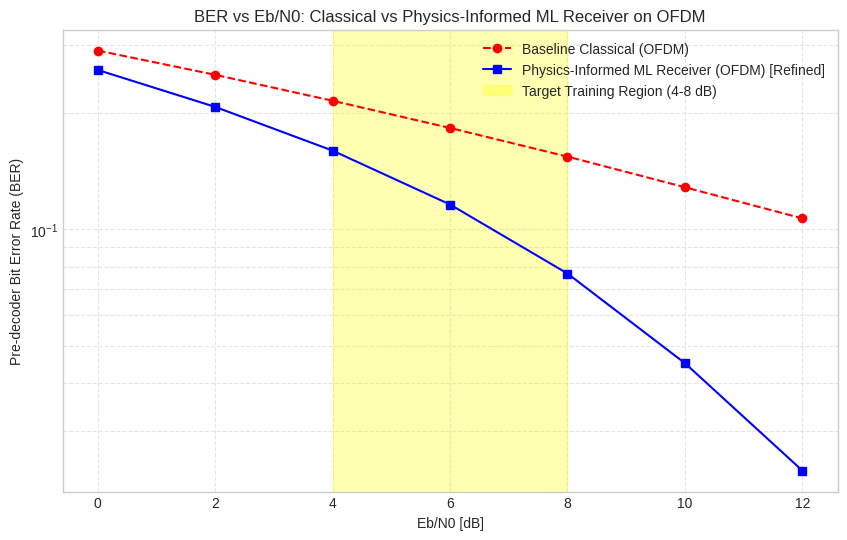

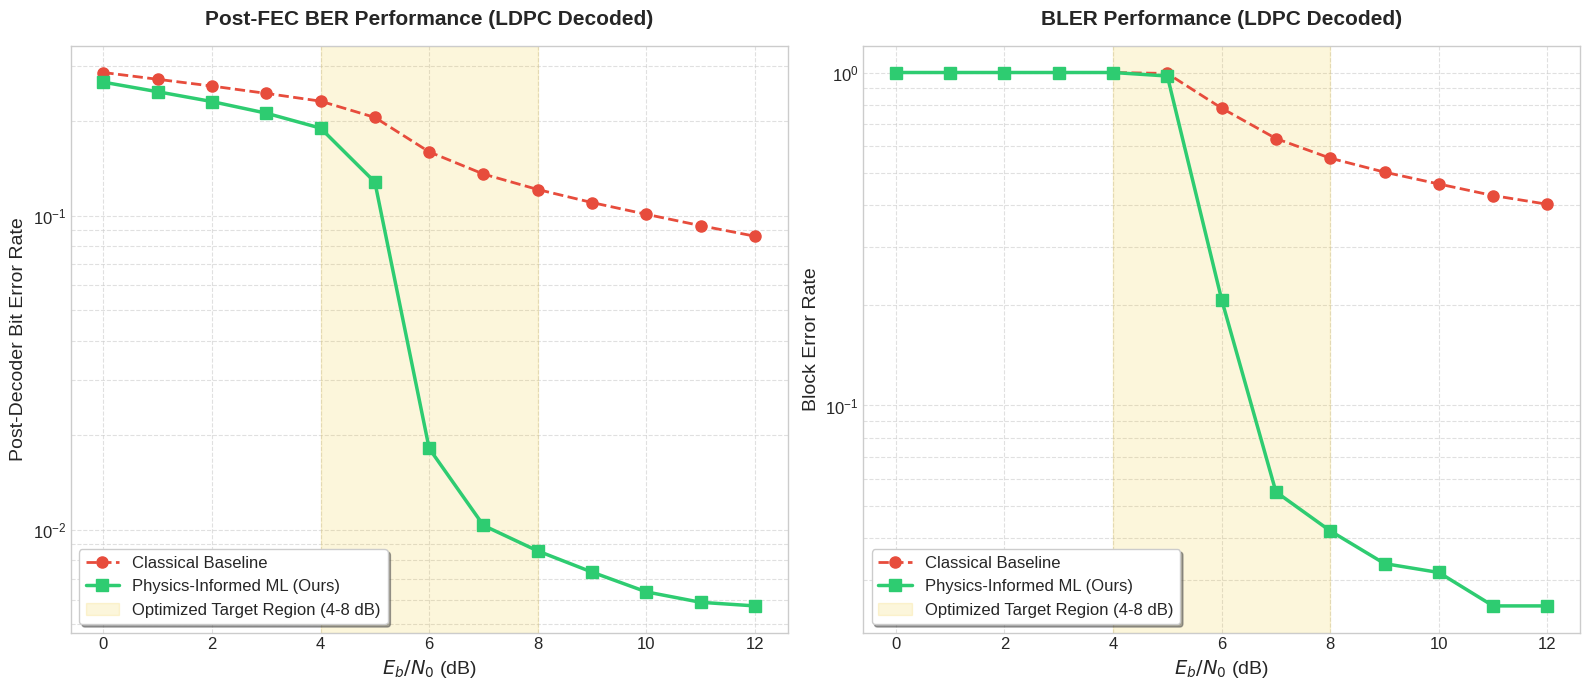

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

# ---- PLOT 1: PRE-FEC BER ----
plt.figure(figsize=(10, 6))
plt.semilogy(ebn0_range, ber_base_ofdm, 'r--o', label='Baseline Classical (OFDM)')
plt.semilogy(ebn0_range, ber_ml_ofdm, 'b-s', label='Physics-Informed ML Receiver (OFDM) [Refined]')
plt.axvspan(4, 8, color='yellow', alpha=0.3, label='Target Training Region (4-8 dB)')
plt.title("BER vs Eb/N0: Classical vs Physics-Informed ML Receiver on OFDM")
plt.xlabel("Eb/N0 [dB]")
plt.ylabel("Pre-decoder Bit Error Rate (BER)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

# ---- PLOT 2 & 3: POST-FEC BER & BLER ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

len_plot = min(len(ebn0_range_post), len(base_post_ber), len(ml_post_ber))
plot_x = list(ebn0_range_post)[:len_plot]

ax1.semilogy(plot_x, base_post_ber[:len_plot], color='#e74c3c', marker='o', linestyle='--',
             linewidth=2, markersize=8, label='Classical Baseline')
ax1.semilogy(plot_x, ml_post_ber[:len_plot], color='#2ecc71', marker='s', linestyle='-',
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax1.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax1.set_title("Post-FEC BER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax1.set_ylabel("Post-Decoder Bit Error Rate", fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.grid(True, which="both", ls="--", alpha=0.6)
ax1.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

ax2.semilogy(plot_x, base_bler[:len_plot], color='#e74c3c', marker='o', linestyle='--',
             linewidth=2, markersize=8, label='Classical Baseline')
ax2.semilogy(plot_x, ml_bler[:len_plot], color='#2ecc71', marker='s', linestyle='-',
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax2.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax2.set_title("BLER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax2.set_ylabel("Block Error Rate", fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.grid(True, which="both", ls="--", alpha=0.6)
ax2.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

### 9.4. Robustness Test: pure e2e black-box (no physics loss guidance)


GENERALIZATION TEST: FRESH 16-QAM DATA (NEW RANDOM SEEDS)
Eb/N0= 0.0 dB | BASE BER=3.631e-01 | ML (Fresh Data) BER=3.320e-01
Eb/N0= 2.0 dB | BASE BER=3.420e-01 | ML (Fresh Data) BER=3.076e-01
Eb/N0= 4.0 dB | BASE BER=3.180e-01 | ML (Fresh Data) BER=2.853e-01
Eb/N0= 6.0 dB | BASE BER=2.678e-01 | ML (Fresh Data) BER=2.312e-01
Eb/N0= 8.0 dB | BASE BER=2.283e-01 | ML (Fresh Data) BER=2.053e-01
Eb/N0=10.0 dB | BASE BER=1.940e-01 | ML (Fresh Data) BER=1.946e-01
Eb/N0=12.0 dB | BASE BER=1.633e-01 | ML (Fresh Data) BER=1.895e-01


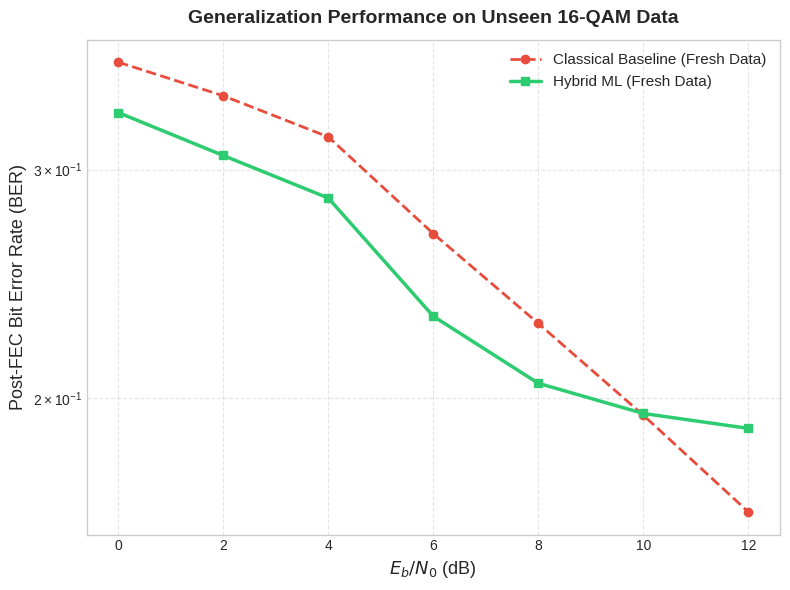

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import tensorflow as tf

print("\n" + "="*80)
print("GENERALIZATION TEST: FRESH 16-QAM DATA (NEW RANDOM SEEDS)")
print("="*80)

# 1. Define the Stress Test Configuration
cfg_fresh = SimConfig(**{
    **cfg_ofdm.__dict__,
    "num_examples": 5000,
    "seed": 999,          # Fresh user data bits

    # --- OUT OF DISTRIBUTION IMPAIRMENTS ---
    # The network was trained on [-2e-4, +2e-4].
    # Let's hit it with 3x the Doppler shift / Frequency Offset.
    "cfo_norm_min": -6e-4,
    "cfo_norm_max": +6e-4,

})

ebn0_range_eval = range(0, 13, 2)
fresh_base_ber, fresh_ml_ber = [], []
eval_batch_size = 500 # Prevents GPU OOM on 5000 examples

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_eval:
        cfg_eval = SimConfig(**{**cfg_fresh.__dict__, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # 2. Generate the fresh, unseen data
        full_tf = simulate_full_frames_tf(cfg_eval)
        ds_eval = generate_dataset_offline(cfg_eval)

        # 3. Classical Baseline Evaluation
        rx_base = classical_receiver(cfg_eval, full_tf)
        fresh_base_ber.append(rx_base["metrics"]["ber_post_info"])

        # 4. ML Model Evaluation (Batched)
        x_rx_t_full = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t_full = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        llr_ml_list = []

        # Process in chunks to keep memory safe
        for b in range(0, 5000, eval_batch_size):
            x_rx_batch = x_rx_t_full[b : b + eval_batch_size]
            x_pilot_batch = x_pilot_t_full[b : b + eval_batch_size]

            # Forward pass
            bit_logits, _, _, _ = model_ofdm(x_rx_batch, x_pilot_batch, mix_ratio=1.0)
            llr_ml_batch = bit_logits.permute(0, 2, 1).reshape(bit_logits.size(0), -1).cpu().numpy()
            llr_ml_list.append(llr_ml_batch)

        llr_ml_np = np.concatenate(llr_ml_list, axis=0)

        # LLR Calibration
        snr_lin = 10 ** (ebno / 10.0)
        scale = snr_lin / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)
        llr_tf = tf.convert_to_tensor(llr_ml_np * scale, dtype=tf.float32)
        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        # LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        ml_ber_v = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        fresh_ml_ber.append(ml_ber_v)

        print(f"Eb/N0={ebno:4.1f} dB | BASE BER={fresh_base_ber[-1]:.3e} | ML (Fresh Data) BER={ml_ber_v:.3e}")

# --- Plotting the Generalization Curve ---
plt.figure(figsize=(8, 6))
plt.semilogy(ebn0_range_eval, fresh_base_ber, color='#e74c3c', marker='o', linestyle='--', linewidth=2, label='Classical Baseline (Fresh Data)')
plt.semilogy(ebn0_range_eval, fresh_ml_ber, color='#2ecc71', marker='s', linestyle='-', linewidth=2.5, label='Hybrid ML (Fresh Data)')
plt.title("Generalization Performance on Unseen 16-QAM Data", fontsize=14, fontweight='bold', pad=12)
plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=13)
plt.ylabel("Post-FEC Bit Error Rate (BER)", fontsize=13)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 10.1. Model training and validation

In [ ]:
train_loader, val_loader = get_pytorch_ofdm_loaders(cfg_ofdm, batch_size=128)

L_time = cfg_ofdm.ofdm_num_data_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)
P_time = cfg_ofdm.ofdm_num_pilot_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)

model_ofdm = HybridNeuralReceiverOFDM(
    seq_len=L_time, n_pilots=P_time,
    ofdm_fft_size=cfg_ofdm.ofdm_fft_size, ofdm_cp_len=cfg_ofdm.ofdm_cp_len
).to(DEVICE)

print(f"Total ML Parameters: {sum(p.numel() for p in model_ofdm.parameters())}")

optimizer = optim.AdamW(model_ofdm.parameters(), lr=2e-3, weight_decay=1e-4)
EPOCHS = 40
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

criterion_bce = nn.BCEWithLogitsLoss()
criterion_mse = nn.MSELoss()

print("\n--- Training Physics-Informed ML Model on OFDM ---")
for epoch in range(EPOCHS):
    model_ofdm.train()
    metrics = {'loss':0, 'phi':0, 'cfo':0, 'ber':0}

    mix = min(1.0, epoch / 10.0)
    aux_w = max(0.05, 1.0 - (epoch / (EPOCHS * 0.75)))

    for x, p, y_p, y_c, target_bits, target_iq in train_loader:
        x, p, y_p, y_c = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
        target_bits, target_iq = target_bits.to(DEVICE), target_iq.to(DEVICE)

        smooth_target_bits = target_bits * 0.98 + 0.01

        optimizer.zero_grad()
        bit_logits, est_phi, est_cfo, est_iq = model_ofdm(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=mix)

        loss_bits = criterion_bce(bit_logits, smooth_target_bits)
        loss_phi = criterion_mse(est_phi, y_p)
        loss_cfo = criterion_mse(est_cfo * 1000.0, y_c * 1000.0)
        loss_iq = criterion_mse(est_iq, target_iq)

        loss = loss_bits + aux_w * (0.5 * loss_phi + 0.5 * loss_cfo + 1.0 * loss_iq)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model_ofdm.parameters(), max_norm=1.0)
        optimizer.step()

        metrics['loss'] += loss.item()
        metrics['phi'] += torch.abs(est_phi - y_p).mean().item()
        with torch.no_grad():
            pred_bits = (bit_logits > 0).float()
            metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    scheduler.step()
    n_train = len(train_loader)

    model_ofdm.eval()
    val_metrics = {'loss':0, 'ber':0}

    with torch.no_grad():
        for x, p, y_p, y_c, target_bits, target_iq in val_loader:
            x, p, y_p, y_c = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
            target_bits, target_iq = target_bits.to(DEVICE), target_iq.to(DEVICE)

            bit_logits, est_phi, est_cfo, est_iq = model_ofdm(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=1.0)

            loss_bits = criterion_bce(bit_logits, target_bits)
            loss_phi = criterion_mse(est_phi, y_p)
            loss_cfo = criterion_mse(est_cfo * 1000.0, y_c * 1000.0)
            loss_iq = criterion_mse(est_iq, target_iq)

            loss = loss_bits + aux_w * (0.5 * loss_phi + 0.5 * loss_cfo + 1.0 * loss_iq)
            val_metrics['loss'] += loss.item()

            pred_bits = (bit_logits > 0).float()
            val_metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    n_val = len(val_loader)

    print(f"Ep {epoch+1:02d}/{EPOCHS} | Mix: {mix:.2f} | "
          f"Train Loss: {metrics['loss']/n_train:.4f} (BER: {metrics['ber']/n_train*100:.2f}%) | "
          f"Val Loss: {val_metrics['loss']/n_val:.4f} (BER: {val_metrics['ber']/n_val*100:.2f}%)")

Generating Specialized OFDM Dataset (80% in 4-8 dB range, 20% generalized)...
Total ML Parameters: 276888

--- Training Physics-Informed ML Model on OFDM ---
Ep 01/40 | Mix: 0.00 | Train Loss: 1.0066 (BER: 23.40%) | Val Loss: 0.8763 (BER: 19.54%)
Ep 02/40 | Mix: 0.10 | Train Loss: 0.5305 (BER: 12.52%) | Val Loss: 0.8173 (BER: 18.81%)
Ep 03/40 | Mix: 0.20 | Train Loss: 0.4660 (BER: 12.35%) | Val Loss: 0.8113 (BER: 18.34%)
Ep 04/40 | Mix: 0.30 | Train Loss: 0.4698 (BER: 12.88%) | Val Loss: 0.7821 (BER: 17.53%)
Ep 05/40 | Mix: 0.40 | Train Loss: 0.4372 (BER: 12.70%) | Val Loss: 0.7604 (BER: 17.43%)
Ep 06/40 | Mix: 0.50 | Train Loss: 0.4291 (BER: 13.01%) | Val Loss: 0.6920 (BER: 16.23%)
Ep 07/40 | Mix: 0.60 | Train Loss: 0.4188 (BER: 13.05%) | Val Loss: 0.6937 (BER: 16.07%)
Ep 08/40 | Mix: 0.70 | Train Loss: 0.4438 (BER: 14.04%) | Val Loss: 0.6902 (BER: 16.08%)
Ep 09/40 | Mix: 0.80 | Train Loss: 0.4373 (BER: 13.90%) | Val Loss: 0.6310 (BER: 14.95%)
Ep 10/40 | Mix: 0.90 | Train Loss: 0.4232

### 10.2. Model evaluation and prints

In [ ]:
import os
os.system('pip install thop -q')
try:
    from thop import profile
    has_thop = True
except ImportError:
    has_thop = False

# --- Highlight Complexity & Efficiency upfront ---
total_params = sum(p.numel() for p in model_ofdm.parameters())
trainable_params = sum(p.numel() for p in model_ofdm.parameters() if p.requires_grad)

print("\n" + "="*105)
print("MODEL COMPLEXITY & EFFICIENCY REPORT")
print("="*105)

print(f"[1] MODEL COMPLEXITY")
print(f" - Total Parameters:     {total_params:,}")
print(f" - Trainable Parameters: {trainable_params:,}")
print(f" - Model Size (Disk):    {total_params * 4 / (1024**2):.2f} MB")

if has_thop:
    try:
        dummy_x = torch.randn(1, 2, L_time).to(DEVICE)
        dummy_p = torch.randn(1, 2, P_time).to(DEVICE)
        dummy_phi = torch.randn(1).to(DEVICE)
        dummy_cfo = torch.randn(1).to(DEVICE)

        macs, params = profile(model_ofdm, inputs=(dummy_x, dummy_p, dummy_phi, dummy_cfo, 1.0), verbose=False)
        print(f" - MACs (Multiplies-Acc):{macs / 1e6:.2f} M")
        print(f" - FLOPs (Approx):       {macs * 2 / 1e6:.2f} MFLOPs")
    except Exception as e:
        print(" - FLOPs: Profiling error.")
else:
    print(" - FLOPs: Install 'thop' (pip install thop) for MACs calculation.")
print("-" * 105)

ebn0_range = range(0, 13, 2)
ber_base_ofdm, ber_ml_ofdm = [], []

print("\n--- Evaluating Baseline vs Physics-Informed ML Model (OFDM) ---")
model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        ber_base_ofdm.append(rx_base["metrics"]["ber_pre_coded"])

        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        target_bits_t = torch.tensor(ds_eval["coded_bits"]).reshape(-1, cfg_ofdm.seq_length, 4).permute(0, 2, 1).float().to(DEVICE)

        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)
        pred_bits = (bit_logits > 0).float()
        ml_ber = (pred_bits != target_bits_t).float().mean().item()
        ber_ml_ofdm.append(ml_ber)

        print(f"Eb/N0 = {ebno:02d} dB | Classical Baseline BER: {ber_base_ofdm[-1]:.4f} | ML BER: {ml_ber:.4f}")

# --- POST-FEC EVALUATION ---
ebn0_range_post = range(0, 13, 1)

base_post_ber, ml_post_ber = [], []
base_bler, ml_bler = [], []

print("\n" + "="*80)
print("POST-FEC BER & BLER EVALUATION (CALIBRATED LLR INTEGRATION)")
print("="*80)

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_post:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # --- CLASSICAL BASELINE ---
        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        m_base = rx_base["metrics"]
        base_post_ber.append(m_base["ber_post_info"])
        base_bler.append(m_base["bler_post_info"])

        # --- ML MODEL ---
        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        # 1. Inference (Raw logits extraction)
        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)
        B = bit_logits.size(0)
        llr_ml_np = bit_logits.permute(0, 2, 1).reshape(B, -1).cpu().numpy()

        # Pre-FEC BER
        pred_bits = (bit_logits > 0).float()
        # ml_pre_ber.append((pred_bits != target_bits_t).float().mean().item())

        # 2. LLR CALIBRATION
        snr_linear = 10 ** (ebno / 10.0)
        confidence_scaler = snr_linear / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)

        llr_tf = tf.convert_to_tensor(llr_ml_np * confidence_scaler, dtype=tf.float32)
        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        # 3. LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        # 4. Metric Calculation
        ml_ber_post = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        ml_bler_val = float(tf.reduce_mean(tf.cast(tf.reduce_any(info_hat != info_tf, axis=1), tf.float32)).numpy())

        ml_post_ber.append(ml_ber_post)
        ml_bler.append(ml_bler_val)

        # RESTORED: Real-time Eb/N0 output prints
        print(f"Eb/N0={ebno:4.1f} dB | BASE postBER={m_base['ber_post_info']:.3e} BLER={m_base['bler_post_info']:.3e} | "
              f"ML postBER={ml_ber_post:.3e} BLER={ml_bler_val:.3e}")


print("\n" + "="*105)
print("FINAL PERFORMANCE REPORT")
print("="*105)

print(f"\n[2] DECODED IMPROVEMENT RANGE (ML vs CLASSICAL)")
print(f"{'Eb/N0 (dB)':<11} | {'Base PostBER':<13} | {'ML PostBER':<13} | {'BER Imp (%)':<12} | {'Base BLER':<13} | {'ML BLER':<13} | {'BLER Imp (%)':<12}")
print("-" * 105)

for i, ebno in enumerate(ebn0_range_post):
    b_ber, m_ber = base_post_ber[i], ml_post_ber[i]
    b_bler, m_bler = base_bler[i], ml_bler[i]

    imp_ber = ((b_ber - m_ber) / b_ber) * 100 if b_ber > 0 else 0.0
    imp_ber_str = f"+{imp_ber:.2f}%" if imp_ber > 0 else f"{imp_ber:.2f}%"

    imp_bler = ((b_bler - m_bler) / b_bler) * 100 if b_bler > 0 else 0.0
    imp_bler_str = f"+{imp_bler:.2f}%" if imp_bler > 0 else f"{imp_bler:.2f}%"

    print(f"{ebno:<11.1f} | {b_ber:<13.3e} | {m_ber:<13.3e} | {imp_ber_str:<12} | {b_bler:<13.3e} | {m_bler:<13.3e} | {imp_bler_str:<12}")


MODEL COMPLEXITY & EFFICIENCY REPORT
[1] MODEL COMPLEXITY
 - Total Parameters:     276,888
 - Trainable Parameters: 276,888
 - Model Size (Disk):    1.06 MB
 - MACs (Multiplies-Acc):36.29 M
 - FLOPs (Approx):       72.57 MFLOPs
---------------------------------------------------------------------------------------------------------

--- Evaluating Baseline vs Physics-Informed ML Model (OFDM) ---
Eb/N0 = 00 dB | Classical Baseline BER: 0.2897 | ML BER: 0.2588
Eb/N0 = 02 dB | Classical Baseline BER: 0.2507 | ML BER: 0.2087
Eb/N0 = 04 dB | Classical Baseline BER: 0.2148 | ML BER: 0.1616
Eb/N0 = 06 dB | Classical Baseline BER: 0.1827 | ML BER: 0.1183
Eb/N0 = 08 dB | Classical Baseline BER: 0.1540 | ML BER: 0.0798
Eb/N0 = 10 dB | Classical Baseline BER: 0.1283 | ML BER: 0.0488
Eb/N0 = 12 dB | Classical Baseline BER: 0.1066 | ML BER: 0.0267

POST-FEC BER & BLER EVALUATION (CALIBRATED LLR INTEGRATION)
Eb/N0= 0.0 dB | BASE postBER=2.851e-01 BLER=1.000e+00 | ML postBER=2.666e-01 BLER=1.000e+00

### 10.3. Plots

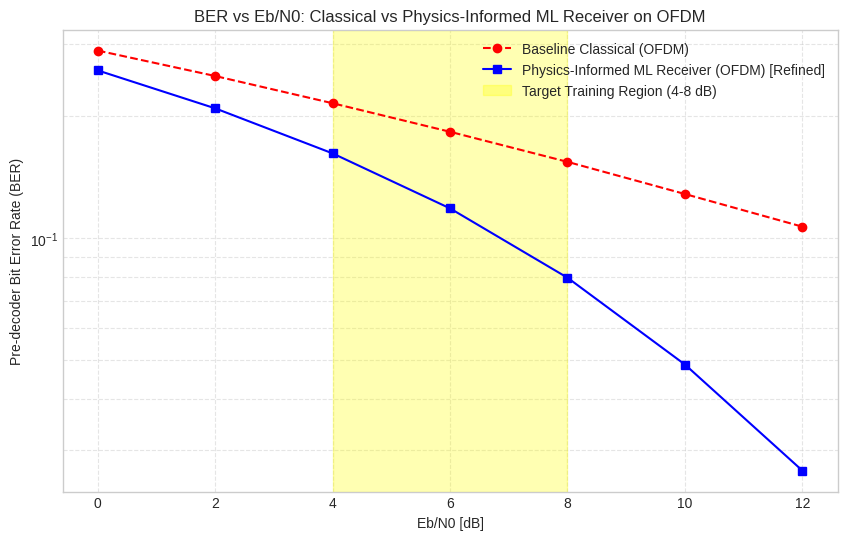

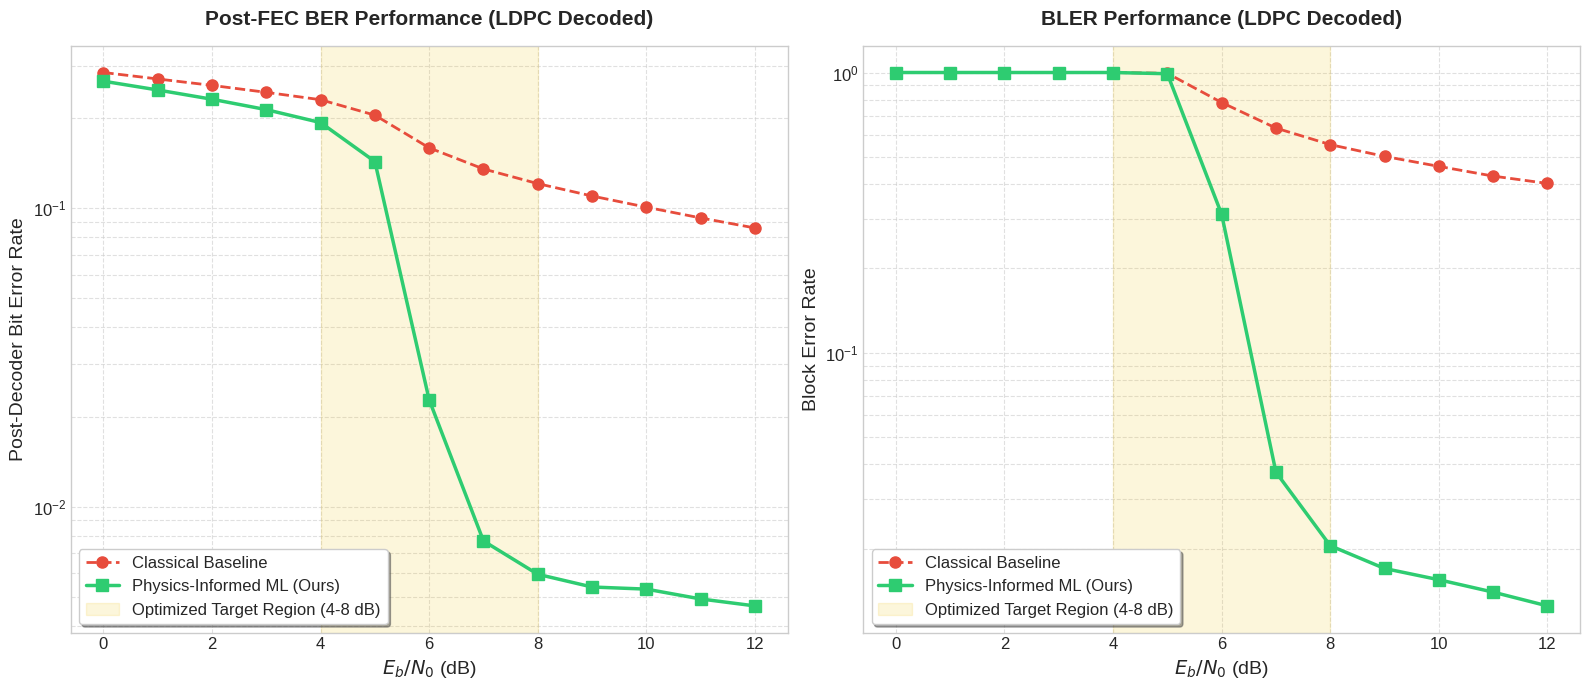

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

# ---- PLOT 1: PRE-FEC BER ----
plt.figure(figsize=(10, 6))
plt.semilogy(ebn0_range, ber_base_ofdm, 'r--o', label='Baseline Classical (OFDM)')
plt.semilogy(ebn0_range, ber_ml_ofdm, 'b-s', label='Physics-Informed ML Receiver (OFDM) [Refined]')
plt.axvspan(4, 8, color='yellow', alpha=0.3, label='Target Training Region (4-8 dB)')
plt.title("BER vs Eb/N0: Classical vs Physics-Informed ML Receiver on OFDM")
plt.xlabel("Eb/N0 [dB]")
plt.ylabel("Pre-decoder Bit Error Rate (BER)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

# ---- PLOT 2 & 3: POST-FEC BER & BLER ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

len_plot = min(len(ebn0_range_post), len(base_post_ber), len(ml_post_ber))
plot_x = list(ebn0_range_post)[:len_plot]

ax1.semilogy(plot_x, base_post_ber[:len_plot], color='#e74c3c', marker='o', linestyle='--',
             linewidth=2, markersize=8, label='Classical Baseline')
ax1.semilogy(plot_x, ml_post_ber[:len_plot], color='#2ecc71', marker='s', linestyle='-',
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax1.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax1.set_title("Post-FEC BER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax1.set_ylabel("Post-Decoder Bit Error Rate", fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.grid(True, which="both", ls="--", alpha=0.6)
ax1.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

ax2.semilogy(plot_x, base_bler[:len_plot], color='#e74c3c', marker='o', linestyle='--',
             linewidth=2, markersize=8, label='Classical Baseline')
ax2.semilogy(plot_x, ml_bler[:len_plot], color='#2ecc71', marker='s', linestyle='-',
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax2.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax2.set_title("BLER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax2.set_ylabel("Block Error Rate", fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.grid(True, which="both", ls="--", alpha=0.6)
ax2.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

### 10.4. Robustness Test: Generalization to Fresh Data


GENERALIZATION TEST: FRESH 16-QAM DATA (NEW RANDOM SEEDS)
Eb/N0= 0.0 dB | BASE BER=3.631e-01 | ML (Fresh Data) BER=3.359e-01
Eb/N0= 2.0 dB | BASE BER=3.420e-01 | ML (Fresh Data) BER=3.120e-01
Eb/N0= 4.0 dB | BASE BER=3.180e-01 | ML (Fresh Data) BER=2.895e-01
Eb/N0= 6.0 dB | BASE BER=2.678e-01 | ML (Fresh Data) BER=2.338e-01
Eb/N0= 8.0 dB | BASE BER=2.283e-01 | ML (Fresh Data) BER=2.049e-01
Eb/N0=10.0 dB | BASE BER=1.940e-01 | ML (Fresh Data) BER=1.938e-01
Eb/N0=12.0 dB | BASE BER=1.633e-01 | ML (Fresh Data) BER=1.881e-01


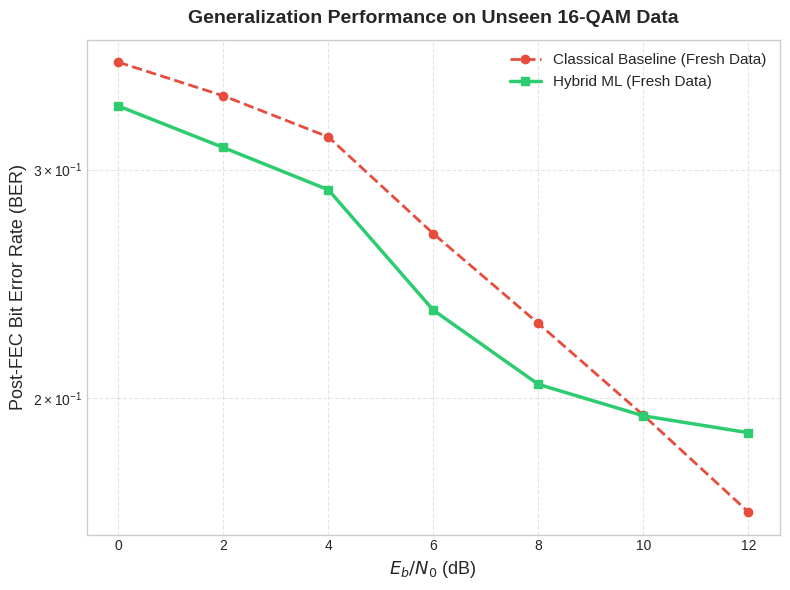

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import tensorflow as tf

print("\n" + "="*80)
print("GENERALIZATION TEST: FRESH 16-QAM DATA (NEW RANDOM SEEDS)")
print("="*80)

# 1. Define the Stress Test Configuration
cfg_fresh = SimConfig(**{
    **cfg_ofdm.__dict__,
    "num_examples": 5000,
    "seed": 999,          # Fresh user data bits

    # --- OUT OF DISTRIBUTION IMPAIRMENTS ---
    # The network was trained on [-2e-4, +2e-4].
    # Let's hit it with 3x the Doppler shift / Frequency Offset.
    "cfo_norm_min": -6e-4,
    "cfo_norm_max": +6e-4,

})

ebn0_range_eval = range(0, 13, 2)
fresh_base_ber, fresh_ml_ber = [], []
eval_batch_size = 500 # Prevents GPU OOM on 5000 examples

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_eval:
        cfg_eval = SimConfig(**{**cfg_fresh.__dict__, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # 2. Generate the fresh, unseen data
        full_tf = simulate_full_frames_tf(cfg_eval)
        ds_eval = generate_dataset_offline(cfg_eval)

        # 3. Classical Baseline Evaluation
        rx_base = classical_receiver(cfg_eval, full_tf)
        fresh_base_ber.append(rx_base["metrics"]["ber_post_info"])

        # 4. ML Model Evaluation (Batched)
        x_rx_t_full = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t_full = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        llr_ml_list = []

        # Process in chunks to keep memory safe
        for b in range(0, 5000, eval_batch_size):
            x_rx_batch = x_rx_t_full[b : b + eval_batch_size]
            x_pilot_batch = x_pilot_t_full[b : b + eval_batch_size]

            # Forward pass
            bit_logits, _, _, _ = model_ofdm(x_rx_batch, x_pilot_batch, mix_ratio=1.0)
            llr_ml_batch = bit_logits.permute(0, 2, 1).reshape(bit_logits.size(0), -1).cpu().numpy()
            llr_ml_list.append(llr_ml_batch)

        llr_ml_np = np.concatenate(llr_ml_list, axis=0)

        # LLR Calibration
        snr_lin = 10 ** (ebno / 10.0)
        scale = snr_lin / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)
        llr_tf = tf.convert_to_tensor(llr_ml_np * scale, dtype=tf.float32)
        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        # LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        ml_ber_v = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        fresh_ml_ber.append(ml_ber_v)

        print(f"Eb/N0={ebno:4.1f} dB | BASE BER={fresh_base_ber[-1]:.3e} | ML (Fresh Data) BER={ml_ber_v:.3e}")

# --- Plotting the Generalization Curve ---
plt.figure(figsize=(8, 6))
plt.semilogy(ebn0_range_eval, fresh_base_ber, color='#e74c3c', marker='o', linestyle='--', linewidth=2, label='Classical Baseline (Fresh Data)')
plt.semilogy(ebn0_range_eval, fresh_ml_ber, color='#2ecc71', marker='s', linestyle='-', linewidth=2.5, label='Hybrid ML (Fresh Data)')
plt.title("Generalization Performance on Unseen 16-QAM Data", fontsize=14, fontweight='bold', pad=12)
plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=13)
plt.ylabel("Post-FEC Bit Error Rate (BER)", fontsize=13)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 11.1. Model training and validation: Static Aux Loss + No Label Smoothing + Curriculum Learning

In [ ]:
train_loader, val_loader = get_pytorch_ofdm_loaders(cfg_ofdm, batch_size=128)

L_time = cfg_ofdm.ofdm_num_data_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)
P_time = cfg_ofdm.ofdm_num_pilot_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)

model_ofdm = HybridNeuralReceiverOFDM(
    seq_len=L_time, n_pilots=P_time,
    ofdm_fft_size=cfg_ofdm.ofdm_fft_size, ofdm_cp_len=cfg_ofdm.ofdm_cp_len
).to(DEVICE)

print(f"Total ML Parameters: {sum(p.numel() for p in model_ofdm.parameters())}")

optimizer = optim.AdamW(model_ofdm.parameters(), lr=2e-3, weight_decay=1e-4)
EPOCHS = 40
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

criterion_bce = nn.BCEWithLogitsLoss()
criterion_mse = nn.MSELoss()

print("\n--- Training Physics-Informed ML Model on OFDM (Best Configuration) ---")
for epoch in range(EPOCHS):
    model_ofdm.train()
    metrics = {'loss':0, 'phi':0, 'cfo':0, 'ber':0}

    # 1. KEEP Curriculum Learning
    mix = min(1.0, epoch / 10.0)

    # 2. STATIC Aux Loss
    aux_w = 1.0

    for x, p, y_p, y_c, target_bits, target_iq in train_loader:
        x, p, y_p, y_c = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
        target_bits, target_iq = target_bits.to(DEVICE), target_iq.to(DEVICE)

        optimizer.zero_grad()
        bit_logits, est_phi, est_cfo, est_iq = model_ofdm(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=mix)

        # 3. NO Label Smoothing (Use raw target_bits.float())
        loss_bits = criterion_bce(bit_logits, target_bits.float())

        loss_phi = criterion_mse(est_phi, y_p)
        loss_cfo = criterion_mse(est_cfo * 1000.0, y_c * 1000.0)
        loss_iq = criterion_mse(est_iq, target_iq)

        loss = loss_bits + aux_w * (0.5 * loss_phi + 0.5 * loss_cfo + 1.0 * loss_iq)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model_ofdm.parameters(), max_norm=1.0)
        optimizer.step()

        metrics['loss'] += loss.item()
        metrics['phi'] += torch.abs(est_phi - y_p).mean().item()
        with torch.no_grad():
            pred_bits = (bit_logits > 0).float()
            metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    scheduler.step()
    n_train = len(train_loader)

    model_ofdm.eval()
    val_metrics = {'loss':0, 'ber':0}

    with torch.no_grad():
        for x, p, y_p, y_c, target_bits, target_iq in val_loader:
            x, p, y_p, y_c = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
            target_bits, target_iq = target_bits.to(DEVICE), target_iq.to(DEVICE)

            bit_logits, est_phi, est_cfo, est_iq = model_ofdm(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=1.0)

            loss_bits = criterion_bce(bit_logits, target_bits.float())
            loss_phi = criterion_mse(est_phi, y_p)
            loss_cfo = criterion_mse(est_cfo * 1000.0, y_c * 1000.0)
            loss_iq = criterion_mse(est_iq, target_iq)

            loss = loss_bits + aux_w * (0.5 * loss_phi + 0.5 * loss_cfo + 1.0 * loss_iq)
            val_metrics['loss'] += loss.item()

            pred_bits = (bit_logits > 0).float()
            val_metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    n_val = len(val_loader)

    print(f"Ep {epoch+1:02d}/{EPOCHS} | Mix: {mix:.2f} | "
          f"Train Loss: {metrics['loss']/n_train:.4f} (BER: {metrics['ber']/n_train*100:.2f}%) | "
          f"Val Loss: {val_metrics['loss']/n_val:.4f} (BER: {val_metrics['ber']/n_val*100:.2f}%)")

Generating Specialized OFDM Dataset (80% in 4-8 dB range, 20% generalized)...


W0000 00:00:1772784413.855846    5955 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Total ML Parameters: 276888

--- Training Physics-Informed ML Model on OFDM (Best Configuration) ---
Ep 01/40 | Mix: 0.00 | Train Loss: 0.9737 (BER: 23.09%) | Val Loss: 0.9882 (BER: 20.88%)
Ep 02/40 | Mix: 0.10 | Train Loss: 0.5065 (BER: 12.36%) | Val Loss: 0.8704 (BER: 18.48%)
Ep 03/40 | Mix: 0.20 | Train Loss: 0.4580 (BER: 12.44%) | Val Loss: 0.9524 (BER: 19.72%)
Ep 04/40 | Mix: 0.30 | Train Loss: 0.4436 (BER: 12.60%) | Val Loss: 0.9127 (BER: 18.85%)
Ep 05/40 | Mix: 0.40 | Train Loss: 0.4322 (BER: 12.86%) | Val Loss: 0.8613 (BER: 18.05%)
Ep 06/40 | Mix: 0.50 | Train Loss: 0.4303 (BER: 12.94%) | Val Loss: 0.8002 (BER: 15.68%)
Ep 07/40 | Mix: 0.60 | Train Loss: 0.4375 (BER: 13.17%) | Val Loss: 0.8688 (BER: 17.13%)
Ep 08/40 | Mix: 0.70 | Train Loss: 0.4370 (BER: 13.51%) | Val Loss: 0.8205 (BER: 16.22%)
Ep 09/40 | Mix: 0.80 | Train Loss: 0.4307 (BER: 13.53%) | Val Loss: 0.8410 (BER: 16.49%)
Ep 10/40 | Mix: 0.90 | Train Loss: 0.4354 (BER: 13.81%) | Val Loss: 0.8215 (BER: 15.27%)
Ep 11/40 

### 11.2. Model evaluation and prints: Static Aux Loss + No Label Smoothing + Curriculum Learning

In [ ]:
import os
os.system('pip install thop -q')
try:
    from thop import profile
    has_thop = True
except ImportError:
    has_thop = False

# --- Highlight Complexity & Efficiency upfront ---
total_params = sum(p.numel() for p in model_ofdm.parameters())
trainable_params = sum(p.numel() for p in model_ofdm.parameters() if p.requires_grad)

print("\n" + "="*105)
print("MODEL COMPLEXITY & EFFICIENCY REPORT")
print("="*105)

print(f"[1] MODEL COMPLEXITY")
print(f" - Total Parameters:     {total_params:,}")
print(f" - Trainable Parameters: {trainable_params:,}")
print(f" - Model Size (Disk):    {total_params * 4 / (1024**2):.2f} MB")

if has_thop:
    try:
        dummy_x = torch.randn(1, 2, L_time).to(DEVICE)
        dummy_p = torch.randn(1, 2, P_time).to(DEVICE)
        dummy_phi = torch.randn(1).to(DEVICE)
        dummy_cfo = torch.randn(1).to(DEVICE)

        macs, params = profile(model_ofdm, inputs=(dummy_x, dummy_p, dummy_phi, dummy_cfo, 1.0), verbose=False)
        print(f" - MACs (Multiplies-Acc):{macs / 1e6:.2f} M")
        print(f" - FLOPs (Approx):       {macs * 2 / 1e6:.2f} MFLOPs")
    except Exception as e:
        print(" - FLOPs: Profiling error.")
else:
    print(" - FLOPs: Install 'thop' (pip install thop) for MACs calculation.")
print("-" * 105)

ebn0_range = range(0, 13, 2)
ber_base_ofdm, ber_ml_ofdm = [], []

print("\n--- Evaluating Baseline vs Physics-Informed ML Model (OFDM) ---")
model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        ber_base_ofdm.append(rx_base["metrics"]["ber_pre_coded"])

        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        target_bits_t = torch.tensor(ds_eval["coded_bits"]).reshape(-1, cfg_ofdm.seq_length, 4).permute(0, 2, 1).float().to(DEVICE)

        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)
        pred_bits = (bit_logits > 0).float()
        ml_ber = (pred_bits != target_bits_t).float().mean().item()
        ber_ml_ofdm.append(ml_ber)

        print(f"Eb/N0 = {ebno:02d} dB | Classical Baseline BER: {ber_base_ofdm[-1]:.4f} | ML BER: {ml_ber:.4f}")

# --- POST-FEC EVALUATION ---
ebn0_range_post = range(0, 13, 1)

base_post_ber, ml_post_ber = [], []
base_bler, ml_bler = [], []

print("\n" + "="*80)
print("POST-FEC BER & BLER EVALUATION (CALIBRATED LLR INTEGRATION)")
print("="*80)

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_post:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # --- CLASSICAL BASELINE ---
        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        m_base = rx_base["metrics"]
        base_post_ber.append(m_base["ber_post_info"])
        base_bler.append(m_base["bler_post_info"])

        # --- ML MODEL ---
        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        # 1. Inference (Raw logits extraction)
        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)
        B = bit_logits.size(0)
        llr_ml_np = bit_logits.permute(0, 2, 1).reshape(B, -1).cpu().numpy()

        # Pre-FEC BER
        pred_bits = (bit_logits > 0).float()
        # ml_pre_ber.append((pred_bits != target_bits_t).float().mean().item())

        # 2. LLR CALIBRATION
        snr_linear = 10 ** (ebno / 10.0)
        confidence_scaler = snr_linear / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)

        llr_tf = tf.convert_to_tensor(llr_ml_np * confidence_scaler, dtype=tf.float32)
        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        # 3. LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        # 4. Metric Calculation
        ml_ber_post = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        ml_bler_val = float(tf.reduce_mean(tf.cast(tf.reduce_any(info_hat != info_tf, axis=1), tf.float32)).numpy())

        ml_post_ber.append(ml_ber_post)
        ml_bler.append(ml_bler_val)

        # RESTORED: Real-time Eb/N0 output prints
        print(f"Eb/N0={ebno:4.1f} dB | BASE postBER={m_base['ber_post_info']:.3e} BLER={m_base['bler_post_info']:.3e} | "
              f"ML postBER={ml_ber_post:.3e} BLER={ml_bler_val:.3e}")


print("\n" + "="*105)
print("FINAL PERFORMANCE REPORT")
print("="*105)

print(f"\n[2] DECODED IMPROVEMENT RANGE (ML vs CLASSICAL)")
print(f"{'Eb/N0 (dB)':<11} | {'Base PostBER':<13} | {'ML PostBER':<13} | {'BER Imp (%)':<12} | {'Base BLER':<13} | {'ML BLER':<13} | {'BLER Imp (%)':<12}")
print("-" * 105)

for i, ebno in enumerate(ebn0_range_post):
    b_ber, m_ber = base_post_ber[i], ml_post_ber[i]
    b_bler, m_bler = base_bler[i], ml_bler[i]

    imp_ber = ((b_ber - m_ber) / b_ber) * 100 if b_ber > 0 else 0.0
    imp_ber_str = f"+{imp_ber:.2f}%" if imp_ber > 0 else f"{imp_ber:.2f}%"

    imp_bler = ((b_bler - m_bler) / b_bler) * 100 if b_bler > 0 else 0.0
    imp_bler_str = f"+{imp_bler:.2f}%" if imp_bler > 0 else f"{imp_bler:.2f}%"

    print(f"{ebno:<11.1f} | {b_ber:<13.3e} | {m_ber:<13.3e} | {imp_ber_str:<12} | {b_bler:<13.3e} | {m_bler:<13.3e} | {imp_bler_str:<12}")


MODEL COMPLEXITY & EFFICIENCY REPORT
[1] MODEL COMPLEXITY
 - Total Parameters:     276,888
 - Trainable Parameters: 276,888
 - Model Size (Disk):    1.06 MB
 - MACs (Multiplies-Acc):36.29 M
 - FLOPs (Approx):       72.57 MFLOPs
---------------------------------------------------------------------------------------------------------

--- Evaluating Baseline vs Physics-Informed ML Model (OFDM) ---
Eb/N0 = 00 dB | Classical Baseline BER: 0.2897 | ML BER: 0.2614
Eb/N0 = 02 dB | Classical Baseline BER: 0.2507 | ML BER: 0.2116
Eb/N0 = 04 dB | Classical Baseline BER: 0.2148 | ML BER: 0.1645
Eb/N0 = 06 dB | Classical Baseline BER: 0.1827 | ML BER: 0.1220
Eb/N0 = 08 dB | Classical Baseline BER: 0.1540 | ML BER: 0.0839
Eb/N0 = 10 dB | Classical Baseline BER: 0.1283 | ML BER: 0.0530
Eb/N0 = 12 dB | Classical Baseline BER: 0.1066 | ML BER: 0.0312

POST-FEC BER & BLER EVALUATION (CALIBRATED LLR INTEGRATION)
Eb/N0= 0.0 dB | BASE postBER=2.851e-01 BLER=1.000e+00 | ML postBER=2.692e-01 BLER=1.000e+00

### 11.3. Plots: Static Aux Loss + No Label Smoothing + Curriculum Learning

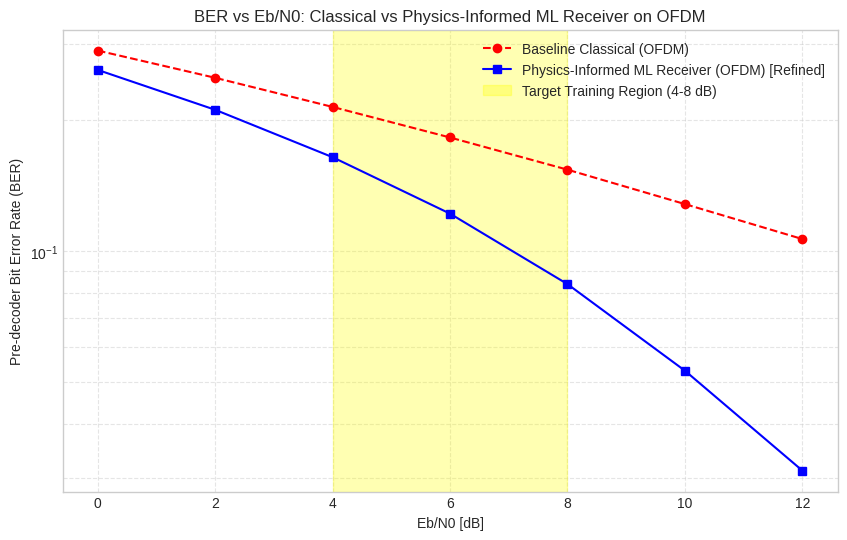

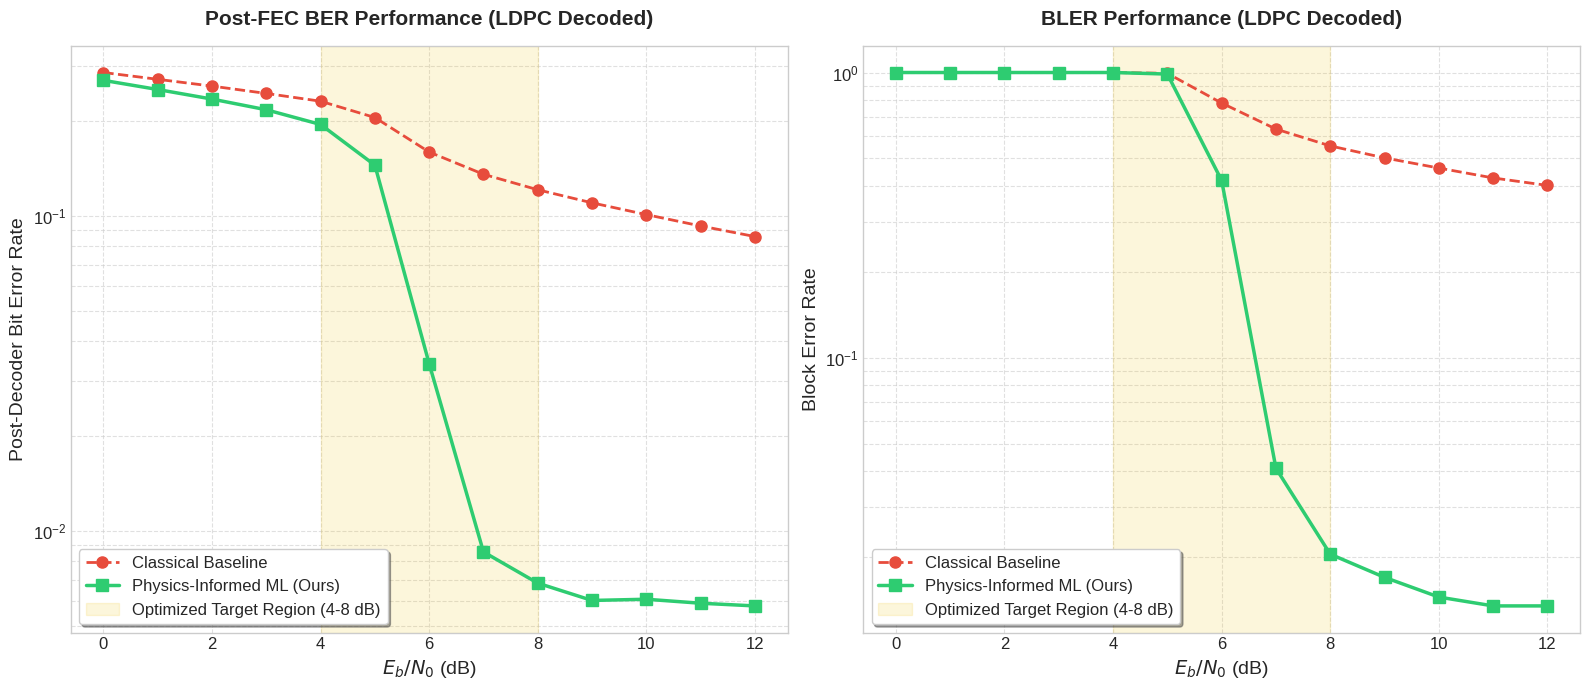

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

# ---- PLOT 1: PRE-FEC BER ----
plt.figure(figsize=(10, 6))
plt.semilogy(ebn0_range, ber_base_ofdm, 'r--o', label='Baseline Classical (OFDM)')
plt.semilogy(ebn0_range, ber_ml_ofdm, 'b-s', label='Physics-Informed ML Receiver (OFDM) [Refined]')
plt.axvspan(4, 8, color='yellow', alpha=0.3, label='Target Training Region (4-8 dB)')
plt.title("BER vs Eb/N0: Classical vs Physics-Informed ML Receiver on OFDM")
plt.xlabel("Eb/N0 [dB]")
plt.ylabel("Pre-decoder Bit Error Rate (BER)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

# ---- PLOT 2 & 3: POST-FEC BER & BLER ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

len_plot = min(len(ebn0_range_post), len(base_post_ber), len(ml_post_ber))
plot_x = list(ebn0_range_post)[:len_plot]

ax1.semilogy(plot_x, base_post_ber[:len_plot], color='#e74c3c', marker='o', linestyle='--',
             linewidth=2, markersize=8, label='Classical Baseline')
ax1.semilogy(plot_x, ml_post_ber[:len_plot], color='#2ecc71', marker='s', linestyle='-',
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax1.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax1.set_title("Post-FEC BER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax1.set_ylabel("Post-Decoder Bit Error Rate", fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.grid(True, which="both", ls="--", alpha=0.6)
ax1.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

ax2.semilogy(plot_x, base_bler[:len_plot], color='#e74c3c', marker='o', linestyle='--',
             linewidth=2, markersize=8, label='Classical Baseline')
ax2.semilogy(plot_x, ml_bler[:len_plot], color='#2ecc71', marker='s', linestyle='-',
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax2.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax2.set_title("BLER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax2.set_ylabel("Block Error Rate", fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.grid(True, which="both", ls="--", alpha=0.6)
ax2.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

### 11.4. Robustness Test: Static Aux Loss + No Label Smoothing + Curriculum Learning


GENERALIZATION TEST: FRESH 16-QAM DATA (NEW RANDOM SEEDS)
Eb/N0= 0.0 dB | BASE BER=3.631e-01 | ML (Fresh Data) BER=3.375e-01
Eb/N0= 2.0 dB | BASE BER=3.420e-01 | ML (Fresh Data) BER=3.152e-01
Eb/N0= 4.0 dB | BASE BER=3.180e-01 | ML (Fresh Data) BER=2.921e-01
Eb/N0= 6.0 dB | BASE BER=2.678e-01 | ML (Fresh Data) BER=2.369e-01
Eb/N0= 8.0 dB | BASE BER=2.283e-01 | ML (Fresh Data) BER=2.070e-01
Eb/N0=10.0 dB | BASE BER=1.940e-01 | ML (Fresh Data) BER=1.966e-01
Eb/N0=12.0 dB | BASE BER=1.633e-01 | ML (Fresh Data) BER=1.931e-01


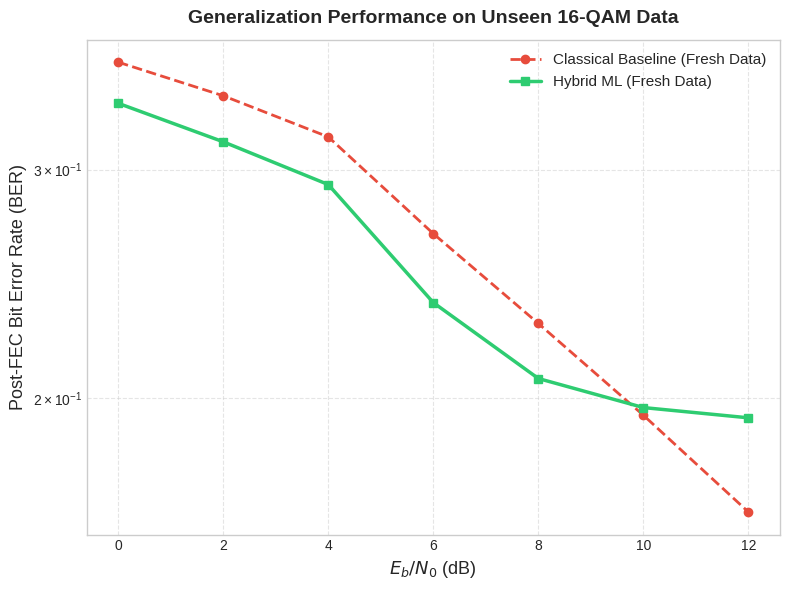

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import tensorflow as tf

print("\n" + "="*80)
print("GENERALIZATION TEST: FRESH 16-QAM DATA (NEW RANDOM SEEDS)")
print("="*80)

# 1. Define the Stress Test Configuration
cfg_fresh = SimConfig(**{
    **cfg_ofdm.__dict__,
    "num_examples": 5000,
    "seed": 999,          # Fresh user data bits

    # --- OUT OF DISTRIBUTION IMPAIRMENTS ---
    # The network was trained on [-2e-4, +2e-4].
    # Let's hit it with 3x the Doppler shift / Frequency Offset.
    "cfo_norm_min": -6e-4,
    "cfo_norm_max": +6e-4,

})

ebn0_range_eval = range(0, 13, 2)
fresh_base_ber, fresh_ml_ber = [], []
eval_batch_size = 500 # Prevents GPU OOM on 5000 examples

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_eval:
        cfg_eval = SimConfig(**{**cfg_fresh.__dict__, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # 2. Generate the fresh, unseen data
        full_tf = simulate_full_frames_tf(cfg_eval)
        ds_eval = generate_dataset_offline(cfg_eval)

        # 3. Classical Baseline Evaluation
        rx_base = classical_receiver(cfg_eval, full_tf)
        fresh_base_ber.append(rx_base["metrics"]["ber_post_info"])

        # 4. ML Model Evaluation (Batched)
        x_rx_t_full = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t_full = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        llr_ml_list = []

        # Process in chunks to keep memory safe
        for b in range(0, 5000, eval_batch_size):
            x_rx_batch = x_rx_t_full[b : b + eval_batch_size]
            x_pilot_batch = x_pilot_t_full[b : b + eval_batch_size]

            # Forward pass
            bit_logits, _, _, _ = model_ofdm(x_rx_batch, x_pilot_batch, mix_ratio=1.0)
            llr_ml_batch = bit_logits.permute(0, 2, 1).reshape(bit_logits.size(0), -1).cpu().numpy()
            llr_ml_list.append(llr_ml_batch)

        llr_ml_np = np.concatenate(llr_ml_list, axis=0)

        # LLR Calibration
        snr_lin = 10 ** (ebno / 10.0)
        scale = snr_lin / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)
        llr_tf = tf.convert_to_tensor(llr_ml_np * scale, dtype=tf.float32)
        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        # LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        ml_ber_v = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        fresh_ml_ber.append(ml_ber_v)

        print(f"Eb/N0={ebno:4.1f} dB | BASE BER={fresh_base_ber[-1]:.3e} | ML (Fresh Data) BER={ml_ber_v:.3e}")

# --- Plotting the Generalization Curve ---
plt.figure(figsize=(8, 6))
plt.semilogy(ebn0_range_eval, fresh_base_ber, color='#e74c3c', marker='o', linestyle='--', linewidth=2, label='Classical Baseline (Fresh Data)')
plt.semilogy(ebn0_range_eval, fresh_ml_ber, color='#2ecc71', marker='s', linestyle='-', linewidth=2.5, label='Hybrid ML (Fresh Data)')
plt.title("Generalization Performance on Unseen 16-QAM Data", fontsize=14, fontweight='bold', pad=12)
plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=13)
plt.ylabel("Post-FEC Bit Error Rate (BER)", fontsize=13)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 12.1. Model training and validation: Dynamic Aux Loss + No Label Smoothing + No Curriculum Learning

In [ ]:
train_loader, val_loader = get_pytorch_ofdm_loaders(cfg_ofdm, batch_size=128)

L_time = cfg_ofdm.ofdm_num_data_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)
P_time = cfg_ofdm.ofdm_num_pilot_symbols * (cfg_ofdm.ofdm_fft_size + cfg_ofdm.ofdm_cp_len)

model_ofdm = HybridNeuralReceiverOFDM(
    seq_len=L_time, n_pilots=P_time,
    ofdm_fft_size=cfg_ofdm.ofdm_fft_size, ofdm_cp_len=cfg_ofdm.ofdm_cp_len
).to(DEVICE)

print(f"Total ML Parameters: {sum(p.numel() for p in model_ofdm.parameters())}")

optimizer = optim.AdamW(model_ofdm.parameters(), lr=2e-3, weight_decay=1e-4)
EPOCHS = 40
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

criterion_bce = nn.BCEWithLogitsLoss()
criterion_mse = nn.MSELoss()

print("\n--- Training Physics-Informed ML Model on OFDM (Comparison Configuration) ---")
for epoch in range(EPOCHS):
    model_ofdm.train()
    metrics = {'loss':0, 'phi':0, 'cfo':0, 'ber':0}

    # 1. NO Curriculum Learning (Hardcoded to 1.0 immediately)
    mix = 1.0

    # 2. NO Static Aux Loss (Dynamic decay)
    aux_w = max(0.05, 1.0 - (epoch / (EPOCHS * 0.75)))

    for x, p, y_p, y_c, target_bits, target_iq in train_loader:
        x, p, y_p, y_c = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
        target_bits, target_iq = target_bits.to(DEVICE), target_iq.to(DEVICE)

        optimizer.zero_grad()
        bit_logits, est_phi, est_cfo, est_iq = model_ofdm(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=mix)

        # 3. NO Label Smoothing (Use raw target_bits.float())
        loss_bits = criterion_bce(bit_logits, target_bits.float())

        loss_phi = criterion_mse(est_phi, y_p)
        loss_cfo = criterion_mse(est_cfo * 1000.0, y_c * 1000.0)
        loss_iq = criterion_mse(est_iq, target_iq)

        loss = loss_bits + aux_w * (0.5 * loss_phi + 0.5 * loss_cfo + 1.0 * loss_iq)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model_ofdm.parameters(), max_norm=1.0)
        optimizer.step()

        metrics['loss'] += loss.item()
        metrics['phi'] += torch.abs(est_phi - y_p).mean().item()
        with torch.no_grad():
            pred_bits = (bit_logits > 0).float()
            metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    scheduler.step()
    n_train = len(train_loader)

    model_ofdm.eval()
    val_metrics = {'loss':0, 'ber':0}

    with torch.no_grad():
        for x, p, y_p, y_c, target_bits, target_iq in val_loader:
            x, p, y_p, y_c = x.to(DEVICE), p.to(DEVICE), y_p.to(DEVICE), y_c.to(DEVICE)
            target_bits, target_iq = target_bits.to(DEVICE), target_iq.to(DEVICE)

            bit_logits, est_phi, est_cfo, est_iq = model_ofdm(x, p, gt_phi=y_p, gt_cfo=y_c, mix_ratio=1.0)

            loss_bits = criterion_bce(bit_logits, target_bits.float())
            loss_phi = criterion_mse(est_phi, y_p)
            loss_cfo = criterion_mse(est_cfo * 1000.0, y_c * 1000.0)
            loss_iq = criterion_mse(est_iq, target_iq)

            loss = loss_bits + aux_w * (0.5 * loss_phi + 0.5 * loss_cfo + 1.0 * loss_iq)
            val_metrics['loss'] += loss.item()

            pred_bits = (bit_logits > 0).float()
            val_metrics['ber'] += (pred_bits != target_bits).float().mean().item()

    n_val = len(val_loader)

    print(f"Ep {epoch+1:02d}/{EPOCHS} | Mix: {mix:.2f} | "
          f"Train Loss: {metrics['loss']/n_train:.4f} (BER: {metrics['ber']/n_train*100:.2f}%) | "
          f"Val Loss: {val_metrics['loss']/n_val:.4f} (BER: {val_metrics['ber']/n_val*100:.2f}%)")

Generating Specialized OFDM Dataset (80% in 4-8 dB range, 20% generalized)...
Total ML Parameters: 276888

--- Training Physics-Informed ML Model on OFDM (Comparison Configuration) ---
Ep 01/40 | Mix: 1.00 | Train Loss: 1.2254 (BER: 31.80%) | Val Loss: 0.8845 (BER: 19.83%)
Ep 02/40 | Mix: 1.00 | Train Loss: 0.6904 (BER: 18.02%) | Val Loss: 0.7952 (BER: 18.86%)
Ep 03/40 | Mix: 1.00 | Train Loss: 0.5761 (BER: 17.43%) | Val Loss: 0.7353 (BER: 17.13%)
Ep 04/40 | Mix: 1.00 | Train Loss: 0.5262 (BER: 15.79%) | Val Loss: 0.7103 (BER: 15.75%)
Ep 05/40 | Mix: 1.00 | Train Loss: 0.4775 (BER: 14.80%) | Val Loss: 0.6779 (BER: 15.03%)
Ep 06/40 | Mix: 1.00 | Train Loss: 0.4525 (BER: 14.58%) | Val Loss: 0.7061 (BER: 16.40%)
Ep 07/40 | Mix: 1.00 | Train Loss: 0.4300 (BER: 14.04%) | Val Loss: 0.6753 (BER: 14.87%)
Ep 08/40 | Mix: 1.00 | Train Loss: 0.4329 (BER: 14.42%) | Val Loss: 0.6638 (BER: 15.23%)
Ep 09/40 | Mix: 1.00 | Train Loss: 0.4074 (BER: 13.75%) | Val Loss: 0.6603 (BER: 15.89%)
Ep 10/40 | Mix

### 12.2. Model evaluation and prints: Dynamic Aux Loss + No Label Smoothing + No Curriculum Learning

In [ ]:
import os
os.system('pip install thop -q')
try:
    from thop import profile
    has_thop = True
except ImportError:
    has_thop = False

# --- Highlight Complexity & Efficiency upfront ---
total_params = sum(p.numel() for p in model_ofdm.parameters())
trainable_params = sum(p.numel() for p in model_ofdm.parameters() if p.requires_grad)

print("\n" + "="*105)
print("MODEL COMPLEXITY & EFFICIENCY REPORT")
print("="*105)

print(f"[1] MODEL COMPLEXITY")
print(f" - Total Parameters:     {total_params:,}")
print(f" - Trainable Parameters: {trainable_params:,}")
print(f" - Model Size (Disk):    {total_params * 4 / (1024**2):.2f} MB")

if has_thop:
    try:
        dummy_x = torch.randn(1, 2, L_time).to(DEVICE)
        dummy_p = torch.randn(1, 2, P_time).to(DEVICE)
        dummy_phi = torch.randn(1).to(DEVICE)
        dummy_cfo = torch.randn(1).to(DEVICE)

        macs, params = profile(model_ofdm, inputs=(dummy_x, dummy_p, dummy_phi, dummy_cfo, 1.0), verbose=False)
        print(f" - MACs (Multiplies-Acc):{macs / 1e6:.2f} M")
        print(f" - FLOPs (Approx):       {macs * 2 / 1e6:.2f} MFLOPs")
    except Exception as e:
        print(" - FLOPs: Profiling error.")
else:
    print(" - FLOPs: Install 'thop' (pip install thop) for MACs calculation.")
print("-" * 105)

ebn0_range = range(0, 13, 2)
ber_base_ofdm, ber_ml_ofdm = [], []

print("\n--- Evaluating Baseline vs Physics-Informed ML Model (OFDM) ---")
model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        ber_base_ofdm.append(rx_base["metrics"]["ber_pre_coded"])

        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        target_bits_t = torch.tensor(ds_eval["coded_bits"]).reshape(-1, cfg_ofdm.seq_length, 4).permute(0, 2, 1).float().to(DEVICE)

        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)
        pred_bits = (bit_logits > 0).float()
        ml_ber = (pred_bits != target_bits_t).float().mean().item()
        ber_ml_ofdm.append(ml_ber)

        print(f"Eb/N0 = {ebno:02d} dB | Classical Baseline BER: {ber_base_ofdm[-1]:.4f} | ML BER: {ml_ber:.4f}")

# --- POST-FEC EVALUATION ---
ebn0_range_post = range(0, 13, 1)

base_post_ber, ml_post_ber = [], []
base_bler, ml_bler = [], []

print("\n" + "="*80)
print("POST-FEC BER & BLER EVALUATION (CALIBRATED LLR INTEGRATION)")
print("="*80)

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_post:
        cfg_eval = SimConfig(**{**cfg_ofdm.__dict__, "num_examples": 2000, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # --- CLASSICAL BASELINE ---
        full_tf = simulate_full_frames_tf(cfg_eval)
        rx_base = classical_receiver(cfg_eval, full_tf)
        m_base = rx_base["metrics"]
        base_post_ber.append(m_base["ber_post_info"])
        base_bler.append(m_base["bler_post_info"])

        # --- ML MODEL ---
        ds_eval = generate_dataset_offline(cfg_eval)
        x_rx_t = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        # 1. Inference (Raw logits extraction)
        bit_logits, _, _, _ = model_ofdm(x_rx_t, x_pilot_t, mix_ratio=1.0)
        B = bit_logits.size(0)
        llr_ml_np = bit_logits.permute(0, 2, 1).reshape(B, -1).cpu().numpy()

        # Pre-FEC BER
        pred_bits = (bit_logits > 0).float()
        # ml_pre_ber.append((pred_bits != target_bits_t).float().mean().item())

        # 2. LLR CALIBRATION
        snr_linear = 10 ** (ebno / 10.0)
        confidence_scaler = snr_linear / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)

        llr_tf = tf.convert_to_tensor(llr_ml_np * confidence_scaler, dtype=tf.float32)
        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        # 3. LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        # 4. Metric Calculation
        ml_ber_post = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        ml_bler_val = float(tf.reduce_mean(tf.cast(tf.reduce_any(info_hat != info_tf, axis=1), tf.float32)).numpy())

        ml_post_ber.append(ml_ber_post)
        ml_bler.append(ml_bler_val)

        # RESTORED: Real-time Eb/N0 output prints
        print(f"Eb/N0={ebno:4.1f} dB | BASE postBER={m_base['ber_post_info']:.3e} BLER={m_base['bler_post_info']:.3e} | "
              f"ML postBER={ml_ber_post:.3e} BLER={ml_bler_val:.3e}")


print("\n" + "="*105)
print("FINAL PERFORMANCE REPORT")
print("="*105)

print(f"\n[2] DECODED IMPROVEMENT RANGE (ML vs CLASSICAL)")
print(f"{'Eb/N0 (dB)':<11} | {'Base PostBER':<13} | {'ML PostBER':<13} | {'BER Imp (%)':<12} | {'Base BLER':<13} | {'ML BLER':<13} | {'BLER Imp (%)':<12}")
print("-" * 105)

for i, ebno in enumerate(ebn0_range_post):
    b_ber, m_ber = base_post_ber[i], ml_post_ber[i]
    b_bler, m_bler = base_bler[i], ml_bler[i]

    imp_ber = ((b_ber - m_ber) / b_ber) * 100 if b_ber > 0 else 0.0
    imp_ber_str = f"+{imp_ber:.2f}%" if imp_ber > 0 else f"{imp_ber:.2f}%"

    imp_bler = ((b_bler - m_bler) / b_bler) * 100 if b_bler > 0 else 0.0
    imp_bler_str = f"+{imp_bler:.2f}%" if imp_bler > 0 else f"{imp_bler:.2f}%"

    print(f"{ebno:<11.1f} | {b_ber:<13.3e} | {m_ber:<13.3e} | {imp_ber_str:<12} | {b_bler:<13.3e} | {m_bler:<13.3e} | {imp_bler_str:<12}")


MODEL COMPLEXITY & EFFICIENCY REPORT
[1] MODEL COMPLEXITY
 - Total Parameters:     276,888
 - Trainable Parameters: 276,888
 - Model Size (Disk):    1.06 MB
 - MACs (Multiplies-Acc):36.29 M
 - FLOPs (Approx):       72.57 MFLOPs
---------------------------------------------------------------------------------------------------------

--- Evaluating Baseline vs Physics-Informed ML Model (OFDM) ---
Eb/N0 = 00 dB | Classical Baseline BER: 0.2897 | ML BER: 0.2606
Eb/N0 = 02 dB | Classical Baseline BER: 0.2507 | ML BER: 0.2101
Eb/N0 = 04 dB | Classical Baseline BER: 0.2148 | ML BER: 0.1625
Eb/N0 = 06 dB | Classical Baseline BER: 0.1827 | ML BER: 0.1193
Eb/N0 = 08 dB | Classical Baseline BER: 0.1540 | ML BER: 0.0805
Eb/N0 = 10 dB | Classical Baseline BER: 0.1283 | ML BER: 0.0491
Eb/N0 = 12 dB | Classical Baseline BER: 0.1066 | ML BER: 0.0273

POST-FEC BER & BLER EVALUATION (CALIBRATED LLR INTEGRATION)
Eb/N0= 0.0 dB | BASE postBER=2.851e-01 BLER=1.000e+00 | ML postBER=2.677e-01 BLER=1.000e+00

### 12.3. Plots: Dynamic Aux Loss + No Label Smoothing + No Curriculum Learning

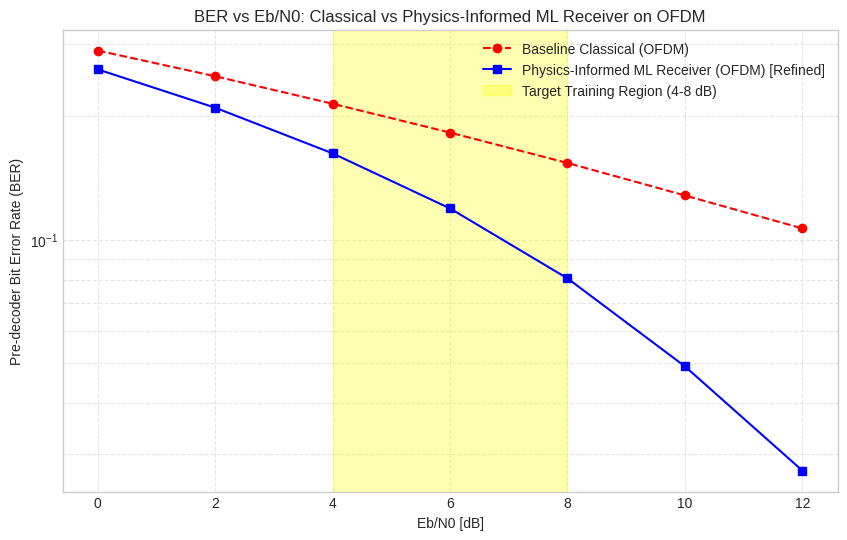

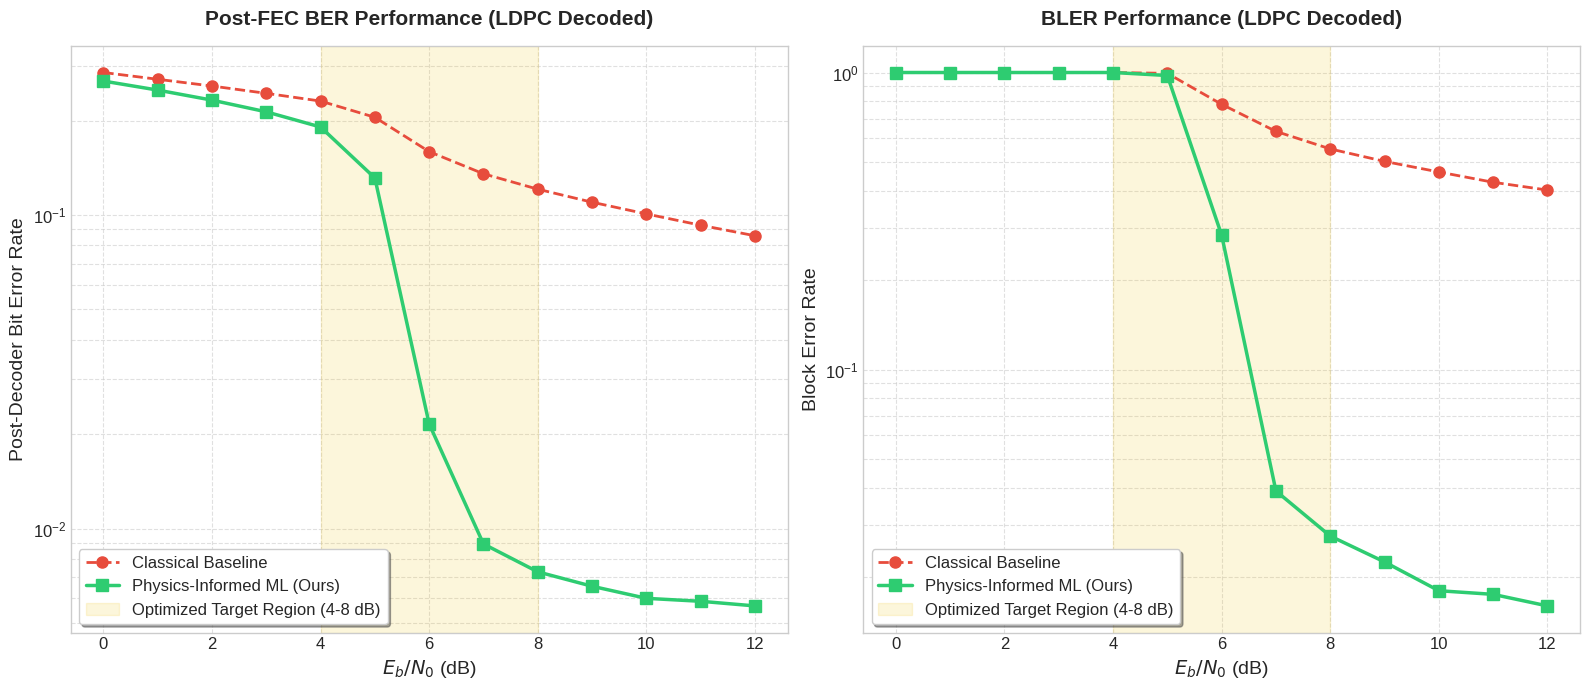

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')

# ---- PLOT 1: PRE-FEC BER ----
plt.figure(figsize=(10, 6))
plt.semilogy(ebn0_range, ber_base_ofdm, 'r--o', label='Baseline Classical (OFDM)')
plt.semilogy(ebn0_range, ber_ml_ofdm, 'b-s', label='Physics-Informed ML Receiver (OFDM) [Refined]')
plt.axvspan(4, 8, color='yellow', alpha=0.3, label='Target Training Region (4-8 dB)')
plt.title("BER vs Eb/N0: Classical vs Physics-Informed ML Receiver on OFDM")
plt.xlabel("Eb/N0 [dB]")
plt.ylabel("Pre-decoder Bit Error Rate (BER)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

# ---- PLOT 2 & 3: POST-FEC BER & BLER ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

len_plot = min(len(ebn0_range_post), len(base_post_ber), len(ml_post_ber))
plot_x = list(ebn0_range_post)[:len_plot]

ax1.semilogy(plot_x, base_post_ber[:len_plot], color='#e74c3c', marker='o', linestyle='--',
             linewidth=2, markersize=8, label='Classical Baseline')
ax1.semilogy(plot_x, ml_post_ber[:len_plot], color='#2ecc71', marker='s', linestyle='-',
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax1.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax1.set_title("Post-FEC BER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax1.set_ylabel("Post-Decoder Bit Error Rate", fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.grid(True, which="both", ls="--", alpha=0.6)
ax1.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

ax2.semilogy(plot_x, base_bler[:len_plot], color='#e74c3c', marker='o', linestyle='--',
             linewidth=2, markersize=8, label='Classical Baseline')
ax2.semilogy(plot_x, ml_bler[:len_plot], color='#2ecc71', marker='s', linestyle='-',
             linewidth=2.5, markersize=8, label='Physics-Informed ML (Ours)')
ax2.axvspan(4, 8, color='#f1c40f', alpha=0.15, label='Optimized Target Region (4-8 dB)')

ax2.set_title("BLER Performance (LDPC Decoded)", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel("$E_b/N_0$ (dB)", fontsize=14)
ax2.set_ylabel("Block Error Rate", fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.grid(True, which="both", ls="--", alpha=0.6)
ax2.legend(fontsize=12, loc='lower left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

### 12.4. Robustness Test: Dynamic Aux Loss + No Label Smoothing + No Curriculum Learning


GENERALIZATION TEST: FRESH 16-QAM DATA (NEW RANDOM SEEDS)
Eb/N0= 0.0 dB | BASE BER=3.631e-01 | ML (Fresh Data) BER=3.353e-01
Eb/N0= 2.0 dB | BASE BER=3.420e-01 | ML (Fresh Data) BER=3.125e-01
Eb/N0= 4.0 dB | BASE BER=3.180e-01 | ML (Fresh Data) BER=2.893e-01
Eb/N0= 6.0 dB | BASE BER=2.678e-01 | ML (Fresh Data) BER=2.338e-01
Eb/N0= 8.0 dB | BASE BER=2.283e-01 | ML (Fresh Data) BER=2.055e-01
Eb/N0=10.0 dB | BASE BER=1.940e-01 | ML (Fresh Data) BER=1.952e-01
Eb/N0=12.0 dB | BASE BER=1.633e-01 | ML (Fresh Data) BER=1.929e-01


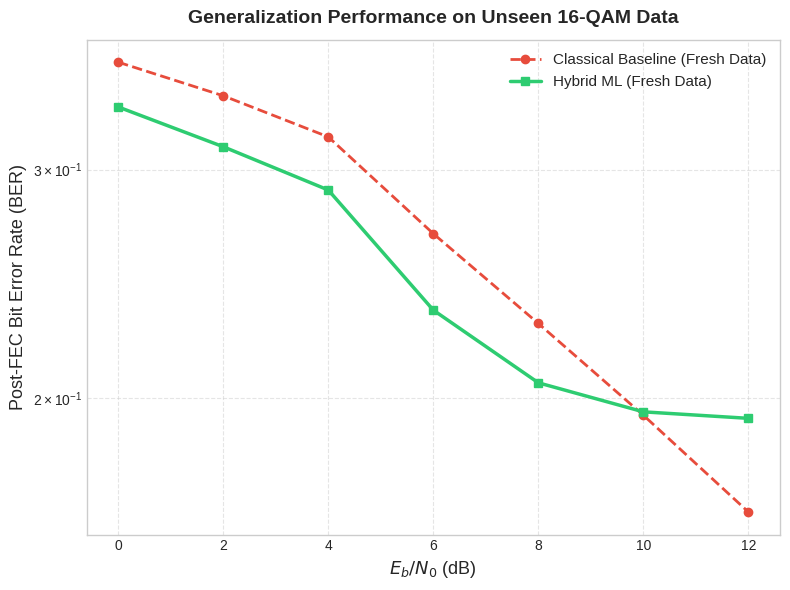

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import tensorflow as tf

print("\n" + "="*80)
print("GENERALIZATION TEST: FRESH 16-QAM DATA (NEW RANDOM SEEDS)")
print("="*80)

# 1. Define the Stress Test Configuration
cfg_fresh = SimConfig(**{
    **cfg_ofdm.__dict__,
    "num_examples": 5000,
    "seed": 999,          # Fresh user data bits

    # --- OUT OF DISTRIBUTION IMPAIRMENTS ---
    # The network was trained on [-2e-4, +2e-4].
    # Let's hit it with 3x the Doppler shift / Frequency Offset.
    "cfo_norm_min": -6e-4,
    "cfo_norm_max": +6e-4,

})

ebn0_range_eval = range(0, 13, 2)
fresh_base_ber, fresh_ml_ber = [], []
eval_batch_size = 500 # Prevents GPU OOM on 5000 examples

model_ofdm.eval()
with torch.no_grad():
    for ebno in ebn0_range_eval:
        cfg_eval = SimConfig(**{**cfg_fresh.__dict__, "ebn0_db_min": float(ebno), "ebn0_db_max": float(ebno)})

        # 2. Generate the fresh, unseen data
        full_tf = simulate_full_frames_tf(cfg_eval)
        ds_eval = generate_dataset_offline(cfg_eval)

        # 3. Classical Baseline Evaluation
        rx_base = classical_receiver(cfg_eval, full_tf)
        fresh_base_ber.append(rx_base["metrics"]["ber_post_info"])

        # 4. ML Model Evaluation (Batched)
        x_rx_t_full = torch.tensor(ds_eval["rx_iq_data_time"]).permute(0, 2, 1).float().to(DEVICE)
        x_pilot_t_full = torch.tensor(ds_eval["rx_iq_pilot_time"]).permute(0, 2, 1).float().to(DEVICE)
        info_bits_np = ds_eval["info_bits"]

        llr_ml_list = []

        # Process in chunks to keep memory safe
        for b in range(0, 5000, eval_batch_size):
            x_rx_batch = x_rx_t_full[b : b + eval_batch_size]
            x_pilot_batch = x_pilot_t_full[b : b + eval_batch_size]

            # Forward pass (mix_ratio=1.0 uses pure model estimation)
            bit_logits, _, _, _ = model_ofdm(x_rx_batch, x_pilot_batch, mix_ratio=1.0)
            llr_ml_batch = bit_logits.permute(0, 2, 1).reshape(bit_logits.size(0), -1).cpu().numpy()
            llr_ml_list.append(llr_ml_batch)

        llr_ml_np = np.concatenate(llr_ml_list, axis=0)

        # LLR Calibration
        snr_lin = 10 ** (ebno / 10.0)
        scale = snr_lin / 4.0 if ebno > 6 else 1.0 + (ebno * 0.5)
        llr_tf = tf.convert_to_tensor(llr_ml_np * scale, dtype=tf.float32)
        info_tf = tf.convert_to_tensor(info_bits_np, dtype=tf.uint8)

        # LDPC Decoding
        _, _, _, _, decoder = build_sionna_blocks(cfg_eval)
        info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)

        ml_ber_v = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
        fresh_ml_ber.append(ml_ber_v)

        print(f"Eb/N0={ebno:4.1f} dB | BASE BER={fresh_base_ber[-1]:.3e} | ML (Fresh Data) BER={ml_ber_v:.3e}")

# --- Plotting the Generalization Curve ---
plt.figure(figsize=(8, 6))
plt.semilogy(ebn0_range_eval, fresh_base_ber, color='#e74c3c', marker='o', linestyle='--', linewidth=2, label='Classical Baseline (Fresh Data)')
plt.semilogy(ebn0_range_eval, fresh_ml_ber, color='#2ecc71', marker='s', linestyle='-', linewidth=2.5, label='Hybrid ML (Fresh Data)')
plt.title("Generalization Performance on Unseen 16-QAM Data", fontsize=14, fontweight='bold', pad=12)
plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=13)
plt.ylabel("Post-FEC Bit Error Rate (BER)", fontsize=13)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()